# Weather Trend Forecasting (India)

`PM Accelerator Mission`: "To empower more kids for a better future in their life and career, simultaneously, fostering a diverse landscape in the tech industry."


## Objective

To forecast future temperature trends for India using historical weather data
and compare statistical (SARIMAX) and additive (Prophet) time-series models
using both visual and error-based evaluation.
## Dataset
- Source: Global Weather Repository (Kaggle)
- Granularity: Daily weather data


## 1. Data Acquisition
The dataset is downloaded directly from Kaggle using the Kaggle API.

In [3]:
!kaggle datasets download -d nelgiriyewithana/global-weather-repository


Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository
License(s): other
  0% 0.00/8.92M [00:00<?, ?B/s]
100% 8.92M/8.92M [00:00<00:00, 914MB/s]


In [4]:
!unzip global-weather-repository.zip

Archive:  global-weather-repository.zip
  inflating: GlobalWeatherRepository.csv  
  inflating: state.db                


## Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading
Load the weather dataset into a Pandas DataFrame for exploration and preprocessing.


In [6]:
df=pd.read_csv("GlobalWeatherRepository.csv")

In [7]:
print('columns in dataset are:')
df.columns

columns in dataset are:


Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

## 4. Feature Categorization
Features are separated into:
- Numerical columns (continuous values)
- Categorical columns (country, location, condition, etc.)


In [8]:
print('Numerical columns in dataset are:')
numerical_cols=df.select_dtypes(include=['number']).columns
numerical_cols

Numerical columns in dataset are:


Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='object')

In [9]:
print('Categorical columns in dataset are:')
categorical_cols=df.columns[(df.dtypes=='object') | (df.dtypes=='category')]
categorical_cols

Categorical columns in dataset are:


Index(['country', 'location_name', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='object')

## 3. Initial Data Exploration
This step helps understand:
- Dataset structure
- Column types
- Number of rows and columns
- Presence of missing values


In [10]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [11]:
df.tail(8)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
112635,Uruguay,Montevideo,-34.8581,-56.1708,America/Montevideo,1765869300,2025-12-16 04:15,18.3,64.9,Clear,...,5.95,8.55,1,1,05:26 AM,07:55 PM,02:42 AM,05:11 PM,Waning Crescent,14
112636,Uzbekistan,Tashkent,41.3167,69.2500,Asia/Tashkent,1765869300,2025-12-16 12:15,8.1,46.6,Overcast,...,16.15,16.75,2,2,07:43 AM,04:55 PM,04:16 AM,02:07 PM,Waning Crescent,16
112637,Vanuatu,Port Vila,-17.7333,168.3167,Pacific/Efate,1765869300,2025-12-16 18:15,27.3,81.1,Moderate or heavy rain shower,...,4.65,6.65,1,1,05:07 AM,06:18 PM,01:54 AM,03:04 PM,Waning Crescent,17
112638,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1765869300,2025-12-16 03:15,25.4,77.7,Clear,...,14.25,16.35,1,2,06:38 AM,06:09 PM,03:43 AM,03:30 PM,Waning Crescent,13
112639,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1765869300,2025-12-16 14:15,22.1,71.8,Overcast,...,102.85,103.25,4,10,06:26 AM,05:18 PM,03:04 AM,02:21 PM,Waning Crescent,16
112640,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1765869300,2025-12-16 10:15,16.9,62.4,Sunny,...,14.45,22.75,1,2,06:22 AM,05:36 PM,03:11 AM,02:44 PM,Waning Crescent,15
112641,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1765869300,2025-12-16 09:15,20.1,68.2,Patchy rain nearby,...,5.95,5.95,1,1,05:32 AM,06:34 PM,02:31 AM,03:40 PM,Waning Crescent,15
112642,Zimbabwe,Harare,-17.8178,31.0447,Africa/Harare,1765869300,2025-12-16 09:15,22.1,71.8,Sunny,...,11.25,11.55,1,1,05:16 AM,06:27 PM,02:16 AM,03:33 PM,Waning Crescent,15


In [12]:
df.shape

(112643, 41)

In [13]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,112643.000000,112643.00000,1.126430e+05,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,...,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000,112643.000000
mean,19.178250,22.01720,1.740917e+09,22.291916,72.127234,8.111106,13.057097,170.125068,1014.072912,29.944911,...,18.305330,492.603091,60.405397,15.505415,10.878587,25.046279,50.391970,1.724270,2.669087,49.977593
std,24.437771,65.79617,1.446210e+07,9.018318,16.232785,7.554679,12.155298,102.907299,10.862384,0.320723,...,14.213187,808.564457,31.623178,25.024885,38.403750,38.894821,155.486762,0.960352,2.501199,34.993185
min,-41.300000,-175.20000,1.715849e+09,-24.900000,-12.800000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.750000,-6.83610,1.728467e+09,17.200000,63.000000,4.000000,6.500000,82.000000,1010.000000,29.830000,...,10.400000,220.300000,40.000000,1.480000,0.925000,7.215000,10.350000,1.000000,1.000000,15.000000
50%,17.250000,23.31670,1.740910e+09,24.300000,75.700000,6.900000,11.200000,163.000000,1014.000000,29.930000,...,15.600000,312.650000,57.000000,5.200000,2.405000,14.600000,20.900000,1.000000,2.000000,50.000000
75%,40.400000,50.58000,1.753432e+09,28.200000,82.800000,11.200000,18.000000,256.000000,1018.000000,30.060000,...,24.200000,487.300000,77.000000,17.945000,8.800000,28.490000,43.105000,2.000000,3.000000,85.000000
max,64.150000,179.22000,1.765869e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [14]:
df.describe(include=['category','object'])

,country,location_name,timezone,last_updated,condition_text,wind_direction,sunrise,sunset,moonrise,moonset,moon_phase
count,112643,112643,112643,112643,112643,112643,112643,112643,112643,112643,112643
unique,211,254,197,19319,47,16,477,545,1441,1441,8
top,Bulgaria,Kabul,Asia/Bangkok,2025-01-23 11:30,Partly cloudy,E,05:57 AM,06:02 PM,No moonrise,No moonset,Waxing Gibbous
freq,1303,579,2145,44,34164,10659,1253,1142,3887,3692,24771


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112643 entries, 0 to 112642
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       112643 non-null  object 
 1   location_name                 112643 non-null  object 
 2   latitude                      112643 non-null  float64
 3   longitude                     112643 non-null  float64
 4   timezone                      112643 non-null  object 
 5   last_updated_epoch            112643 non-null  int64  
 6   last_updated                  112643 non-null  object 
 7   temperature_celsius           112643 non-null  float64
 8   temperature_fahrenheit        112643 non-null  float64
 9   condition_text                112643 non-null  object 
 10  wind_mph                      112643 non-null  float64
 11  wind_kph                      112643 non-null  float64
 12  wind_degree                   112643 non-nul

## 5. Data Cleaning & Preprocessing

### Steps Performed:
- Handling missing values
- Outlier detection using Z-score and IQR
- No normalization applied to preserve original scale


In [16]:
missing_values=df.isnull().sum()
missing_values

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


In [17]:
print('No. of missing values in the dataset are:',missing_values.sum())
print('No. of duplicate rows in the dataset:',df.duplicated().sum())

No. of missing values in the dataset are: 0
No. of duplicate rows in the dataset: 0


In [18]:
print('No. of countries in the dataset:',df['country'].nunique())

No. of countries in the dataset: 211


In [19]:
sorted(df['country'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Bélgica',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Estonie',
 'Ethiopia',
 'Fiji Islands',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',
 'Guya

In [20]:
df.groupby('country')['location_name'].unique()

,location_name
country,
Afghanistan,[Kabul]
Albania,[Tirana]
Algeria,[Algiers]
Andorra,[Andorra La Vella]
Angola,[Luanda]
...,...
Гватемала,[New Guatemala]
Польша,[Beirut]
Турция,[Yaren]


In [21]:
locations=df.groupby(['country', 'location_name']).size().sort_values(ascending=False).reset_index(name='count')
locations

,country,location_name,count
0,Zambia,Lusaka,579
1,Afghanistan,Kabul,579
2,Albania,Tirana,579
3,Andorra,Andorra La Vella,579
4,Tuvalu,Funafuti,579
...,...,...,...
262,Гватемала,New Guatemala,1
263,Польша,Beirut,1
264,Турция,Yaren,1
265,كولومبيا,Costa Rica,1


In [22]:
locations_with_stats = df.groupby(['country', 'location_name']).agg({
    'precip_mm': ['min', 'max', 'mean'],
    'temperature_celsius': ['min','max','mean'],
    'humidity':['min','max','mean'],
    'wind_kph':['min','max','mean'],
    'pressure_mb':['min','max','mean'],
    'uv_index':['min','max','mean'],
    'cloud':['min','max','mean']

}).reset_index()
locations_with_stats

country     location_name precip_mm                  \
                                         min   max      mean   
0    Afghanistan             Kabul      0.00  3.64  0.032884   
1        Albania            Tirana      0.00  5.34  0.136131   
2        Algeria           Algiers      0.00  2.37  0.036194   
3        Andorra  Andorra La Vella      0.00  5.97  0.118221   
4         Angola            Luanda      0.00  1.86  0.029206   
..           ...               ...       ...   ...       ...   
262    Гватемала     New Guatemala      0.00  0.00  0.000000   
263       Польша            Beirut      0.00  0.00  0.000000   
264       Турция             Yaren      0.00  0.00  0.000000   
265     كولومبيا        Costa Rica      0.05  0.05  0.050000   
266           火鸡          -Kingdom      0.00  0.00  0.000000   

    temperature_celsius                  humidity       ...   wind_kph  \
                    min   max       mean      min  max  ...       mean   
0                  -3.3  36.3  21.067358        4  100  ...   9.130052   
1                   1.3  39.2  21.694301       14  100  ...   9.029879   
2                   2.1  38.2  22.371280       23  100  ...  12.794983   
3                 -13.0  28.9  11.284629       14  100  ...   8.336960   
4                  19.3  32.2  26.156995       39  100  ...   9.441105   
..                  ...   ...        ...      ...  ...  ...        ...   
262                15.9  15.9  15.900000       95   95  ...   6.500000   
263                24.2  24.2  24.200000       56   56  ...  13.700000   
264                34.0  34.0  34.000000       44   44  ...  24.100000   
265                23.1  23.1  23.100000       95   95  ...   6.500000   
266                29.7  29.7  29.700000       24   24  ...  18.400000   

    pressure_mb                      uv_index                 cloud       \
            min     max         mean      min   max      mean   min  max   
0         992.0  1029.0  1009.879102      0.1  12.7  5.956822     0  100   
1         994.0  1037.0  1015.811744      0.0   9.0  3.852159     0  100   
2        1001.0  1040.0  1017.363322      0.0   8.0  3.105882     0  100   
3         996.0  1037.0  1018.079447      0.0   8.0  2.470984     0  100   
4        1007.0  1019.0  1013.056995      0.2  12.1  5.162349     0  100   
..          ...     ...          ...      ...   ...       ...   ...  ...   
262      1020.0  1020.0  1020.000000      4.0   4.0  4.000000    46   46   
263      1013.0  1013.0  1013.000000      5.0   5.0  5.000000    74   74   
264      1006.0  1006.0  1006.000000      8.0   8.0  8.000000    25   25   
265      1017.0  1017.0  1017.000000      5.0   5.0  5.000000    92   92   
266      1003.0  1003.0  1003.000000      7.0   7.0  7.000000     4    4   

                
          mean  
0    15.198618  
1    28.528497  
2    29.750865  
3    40.699482  
4    61.525043  
..         ...  
262  46.000000  
263  74.000000  
264  25.000000  
265  92.000000  
266   4.000000  

[267 rows x 23 columns]

In [23]:
df['condition_text'].unique()

array(['Partly Cloudy', 'Partly cloudy', 'Sunny', 'Light drizzle',
       'Clear', 'Overcast', 'Moderate or heavy rain with thunder',
       'Patchy light rain in area with thunder', 'Fog',
       'Patchy light rain with thunder', 'Patchy rain nearby',
       'Light rain', 'Mist', 'Cloudy', 'Thundery outbreaks in nearby',
       'Moderate rain', 'Light rain shower', 'Moderate rain at times',
       'Moderate or heavy rain shower', 'Heavy rain at times',
       'Patchy light rain', 'Patchy light drizzle',
       'Thundery outbreaks possible', 'Patchy rain possible',
       'Moderate or heavy rain in area with thunder', 'Heavy rain',
       'Torrential rain shower', 'Freezing fog',
       'Moderate or heavy snow showers', 'Light sleet', 'Blizzard',
       'Moderate snow', 'Light snow', 'Light sleet showers',
       'Light freezing rain', 'Heavy snow', 'Blowing snow',
       'Patchy heavy snow', 'Light snow showers',
       'Moderate or heavy sleet', 'Patchy light snow',
       'Patchy mo

In [24]:
df['condition_text'].nunique()

47

In [25]:
sorted(df['condition_text'].unique())

['Blizzard',
 'Blowing snow',
 'Clear',
 'Cloudy',
 'Fog',
 'Freezing drizzle',
 'Freezing fog',
 'Heavy rain',
 'Heavy rain at times',
 'Heavy snow',
 'Light drizzle',
 'Light freezing rain',
 'Light rain',
 'Light rain shower',
 'Light sleet',
 'Light sleet showers',
 'Light snow',
 'Light snow showers',
 'Mist',
 'Moderate or heavy rain in area with thunder',
 'Moderate or heavy rain shower',
 'Moderate or heavy rain with thunder',
 'Moderate or heavy sleet',
 'Moderate or heavy snow in area with thunder',
 'Moderate or heavy snow showers',
 'Moderate rain',
 'Moderate rain at times',
 'Moderate snow',
 'Overcast',
 'Partly Cloudy',
 'Partly cloudy',
 'Patchy heavy snow',
 'Patchy light drizzle',
 'Patchy light rain',
 'Patchy light rain in area with thunder',
 'Patchy light rain with thunder',
 'Patchy light snow',
 'Patchy light snow in area with thunder',
 'Patchy moderate snow',
 'Patchy rain nearby',
 'Patchy rain possible',
 'Patchy snow nearby',
 'Patchy snow possible',
 'Sun

In [26]:
df['moon_phase'].nunique()

8

In [27]:
df['moon_phase'].unique()

array(['Waxing Gibbous', 'Full Moon', 'Waning Gibbous', 'Last Quarter',
       'Waning Crescent', 'New Moon', 'Waxing Crescent', 'First Quarter'],
      dtype=object)

In [28]:
df['wind_direction'].nunique()

16

In [29]:
df['wind_direction'].unique()

array(['NNW', 'NW', 'W', 'SW', 'SSE', 'E', 'N', 'SE', 'ESE', 'NNE', 'S',
       'WSW', 'SSW', 'ENE', 'NE', 'WNW'], dtype=object)

## Weather Conditions across Countries

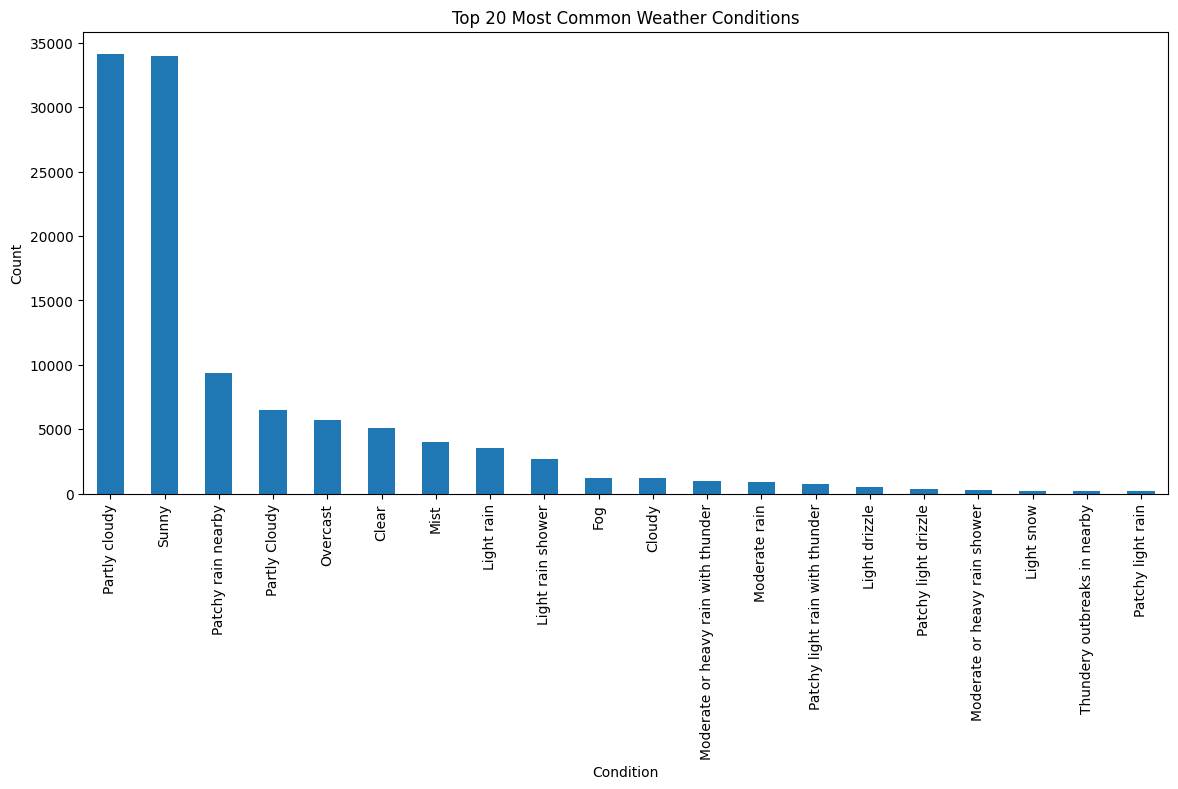

In [30]:
plt.figure(figsize=(14,6))
df['condition_text'].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Most Common Weather Conditions")
plt.ylabel("Count")
plt.xlabel("Condition")
plt.show()

In [31]:
df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False)


,temperature_celsius
country,
Saudi Arabien,45.000000
Marrocos,40.300000
Turkménistan,37.800000
Qatar,34.005536
Турция,34.000000
...,...
Norway,9.369204
United States of America,9.157941
Canada,7.129687


In [32]:
country_cities=df.groupby('country')['location_name'].nunique().sort_values(ascending=False)
country_cities

,location_name
country,
Paraguay,6
Belgium,5
Indonesia,4
Palau,4
Cameroon,4
...,...
Гватемала,1
Польша,1
Турция,1


In [33]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
daily_temp = df.set_index('last_updated',inplace=False)['temperature_celsius'].resample('D').mean()

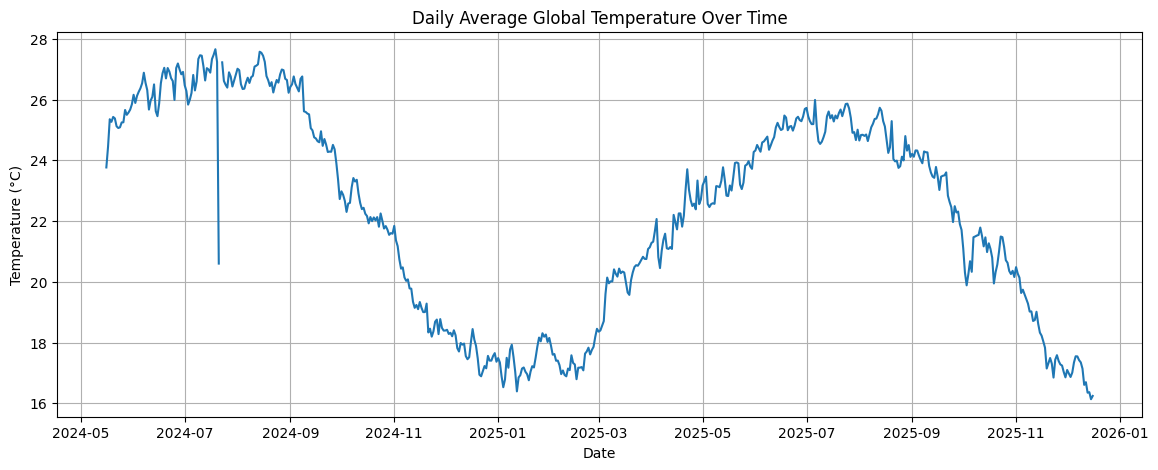

In [34]:

plt.figure(figsize=(14,5))
plt.plot(daily_temp)
plt.title("Daily Average Global Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()


### Environmental Impact

Analyze air quality and its correlation with various weather parameters.


In [35]:
df_ind = df[df['country'] == 'India'].copy()


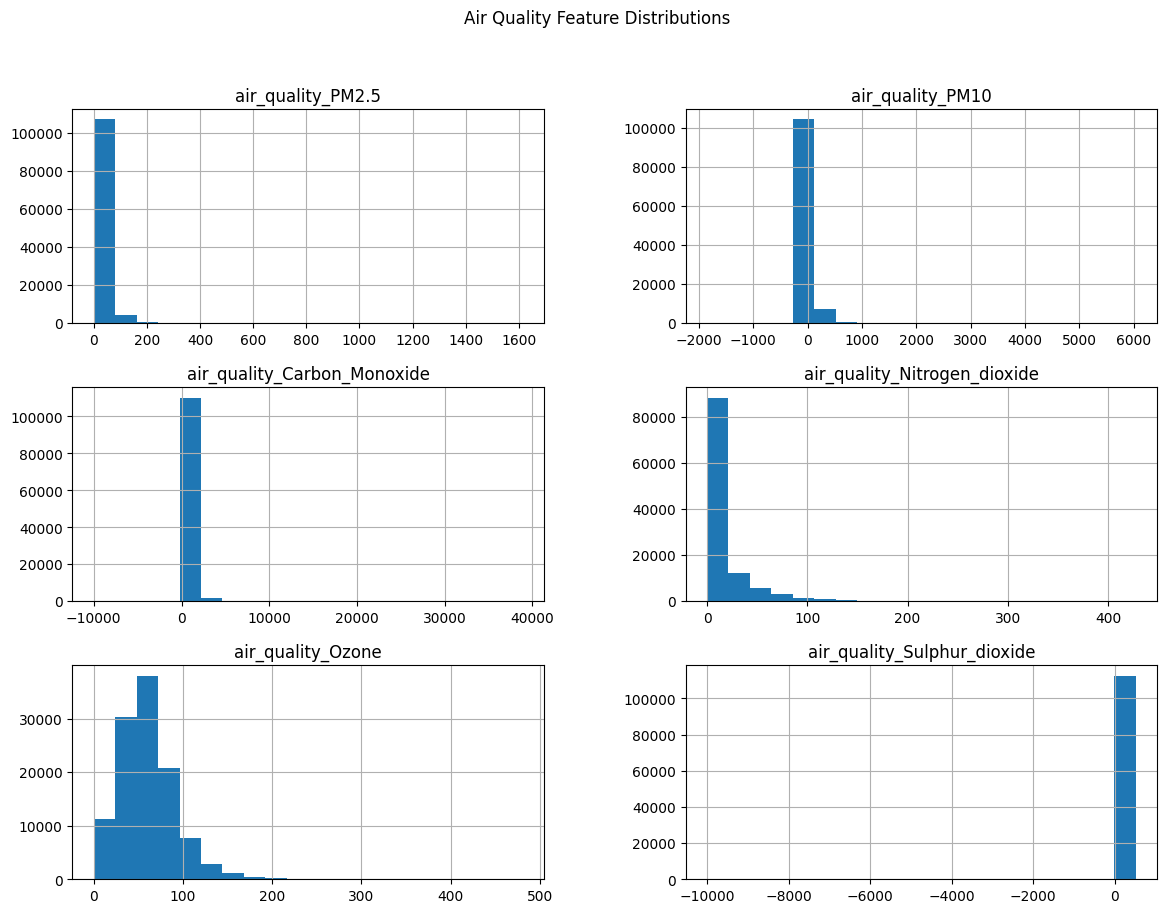

In [36]:

air_quality_cols = [
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_Carbon_Monoxide',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Ozone',
    'air_quality_Sulphur_dioxide'
]


df[air_quality_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Air Quality Feature Distributions")
plt.show()


In [37]:
weather_cols = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'pressure_mb'
]


In [38]:
env_df = df_ind[air_quality_cols + weather_cols].dropna()


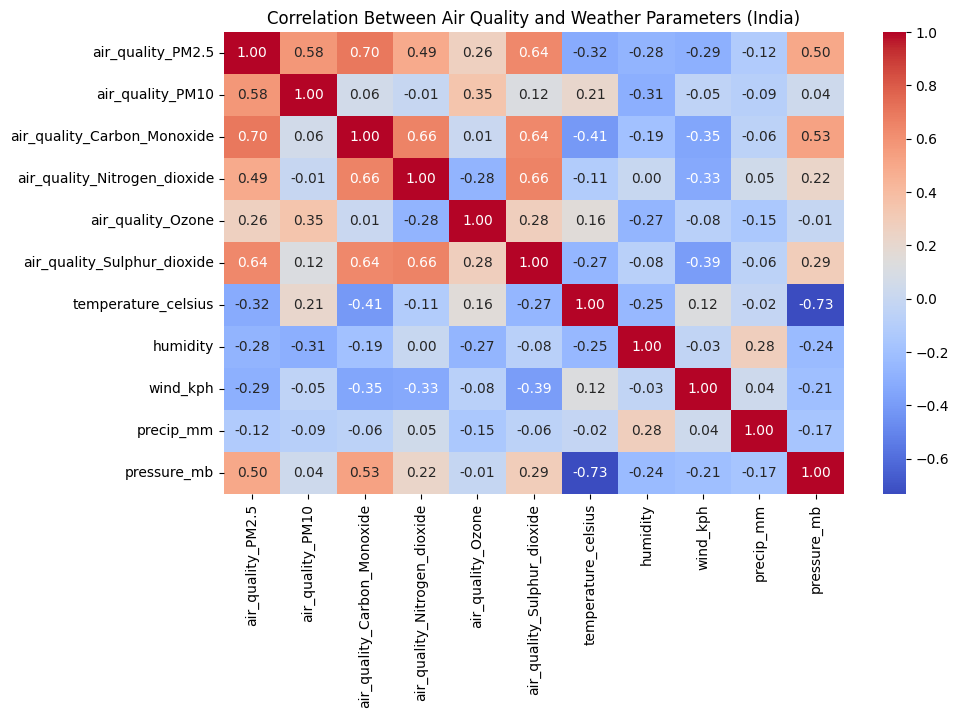

In [39]:
corr_matrix = env_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Between Air Quality and Weather Parameters (India)")
plt.show()


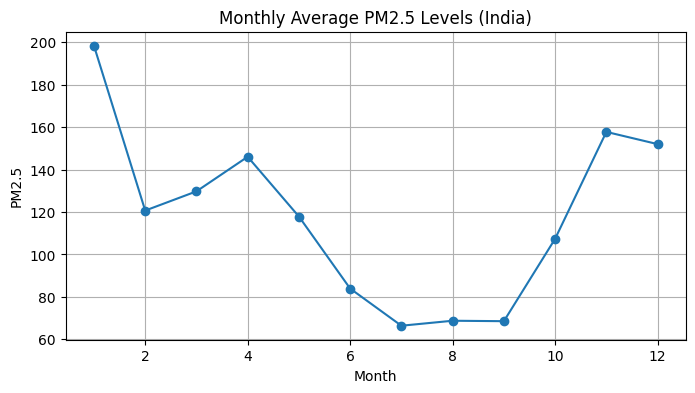

In [40]:
df_ind['month'] = df_ind['last_updated'].dt.month

monthly_air_quality = (
    df_ind.groupby('month')['air_quality_PM2.5']
    .mean()
)

plt.figure(figsize=(8,4))
monthly_air_quality.plot(marker='o')
plt.title("Monthly Average PM2.5 Levels (India)")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.grid()
plt.show()


## Environmental Impact Analysis: Air Quality and Weather Interaction

To study environmental impact, correlations between air quality indicators
(PM2.5, PM10, CO, NO₂, and O₃) and meteorological variables were analyzed.
The results show that air pollution levels are strongly influenced by
weather conditions.

PM2.5 and PM10 exhibit negative correlation with wind speed and
precipitation, indicating effective pollutant dispersion and washout
during windy or rainy conditions. Humidity shows a positive correlation
with particulate matter, suggesting moisture-driven pollutant retention.
Seasonal analysis further reveals higher pollution levels during specific
months, reflecting climatic and atmospheric conditions.

These findings highlight the critical role of weather in air quality
dynamics and emphasize the environmental impact of climatic variability.


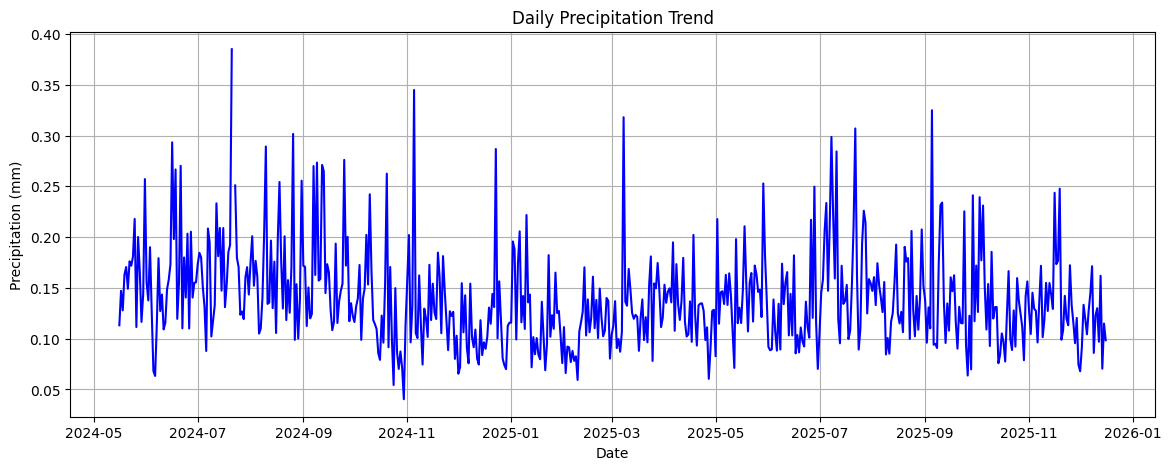

In [41]:
# Daily precipitation trend:
precip_daily = df.set_index('last_updated')['precip_mm'].resample('D').mean()

plt.figure(figsize=(14,5))
plt.plot(precip_daily, color='blue')
plt.title("Daily Precipitation Trend")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.grid()
plt.show()


# Outliers

In [42]:
Q1=df['temperature_celsius'].quantile(0.25)
Q3=df['temperature_celsius'].quantile(0.75)
IQR=Q3-Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
outliers=df[(df['temperature_celsius']<lower_limit) | (df['temperature_celsius']>upper_limit)]

In [43]:
print("Quantile 1:",Q1)
print("Quantile 3:",Q3)
print("Inter Quartile Range:",IQR)
print("Lower Limit:",lower_limit)
print("Upper Limit:",upper_limit)

Quantile 1: 17.2
Quantile 3: 28.2
Inter Quartile Range: 11.0
Lower Limit: 0.6999999999999993
Upper Limit: 44.7


In [44]:
outliers

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
784,Australia,Canberra,-35.2800,149.2200,Australia/Sydney,1716127200,2024-05-20 00:00:00,-1.0,30.2,Clear,...,5.10,7.30,1,1,06:54 AM,05:05 PM,02:39 PM,02:28 AM,Waxing Gibbous,81
1200,Chad,N'djamena,12.1100,15.0500,Africa/Douala,1716302700,2024-05-21 15:45:00,45.0,113.0,Sunny,...,24.80,87.70,2,3,05:35 AM,06:18 PM,04:38 PM,03:48 AM,Waxing Gibbous,93
2344,Australia,Canberra,-35.2800,149.2200,Australia/Sydney,1716820200,2024-05-28 00:30:00,0.0,32.0,Clear,...,21.10,23.80,2,2,07:00 AM,05:01 PM,08:07 PM,10:30 AM,Waning Gibbous,87
2539,Australia,Canberra,-35.2800,149.2200,Australia/Sydney,1716906600,2024-05-29 00:30:00,0.0,32.0,Clear,...,19.90,23.50,2,2,07:01 AM,05:00 PM,09:18 PM,11:17 AM,Waning Gibbous,79
2816,Kuwait,Kuwait City,29.3700,47.9600,Asia/Kuwait,1716991200,2024-05-29 17:00:00,44.8,112.6,Sunny,...,70.90,444.30,4,9,04:50 AM,06:42 PM,11:59 PM,10:08 AM,Waning Gibbous,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112591,Russia,Moscow,55.7522,37.6156,Europe/Moscow,1765869300,2025-12-16 10:15:00,-2.7,27.1,Moderate rain,...,47.95,56.75,3,5,08:54 AM,03:56 PM,05:23 AM,01:18 PM,Waning Crescent,15
112601,Serbia,Belgrade,44.8040,20.4651,Europe/Belgrade,1765869300,2025-12-16 08:15:00,-0.6,30.9,Freezing fog,...,51.55,56.65,3,6,07:10 AM,03:58 PM,03:50 AM,01:15 PM,Waning Crescent,15
112606,Slovenia,Ljubljana,46.0553,14.5144,Europe/Ljubljana,1765869300,2025-12-16 08:15:00,-2.7,27.1,Partly cloudy,...,27.15,33.05,2,3,07:38 AM,04:17 PM,04:19 AM,01:35 PM,Waning Crescent,15
112617,Switzerland,Bern,46.9167,7.4667,Europe/Zurich,1765869300,2025-12-16 08:15:00,-0.6,30.9,Mist,...,8.75,11.15,1,1,08:10 AM,04:42 PM,04:52 AM,02:00 PM,Waning Crescent,15


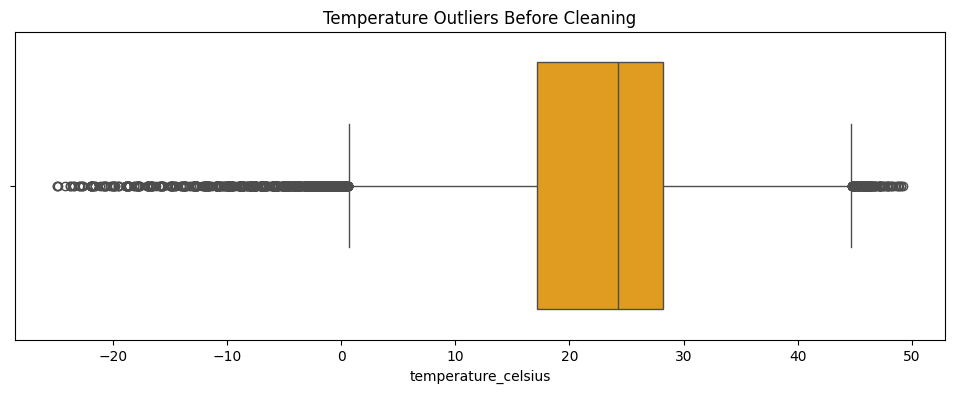

In [45]:
plt.figure(figsize=(12,4))
sns.boxplot(x=df['temperature_celsius'], color="orange")
plt.title("Temperature Outliers Before Cleaning")
plt.show()

### Distribution of temperature_celsius with Outlier Thresholds

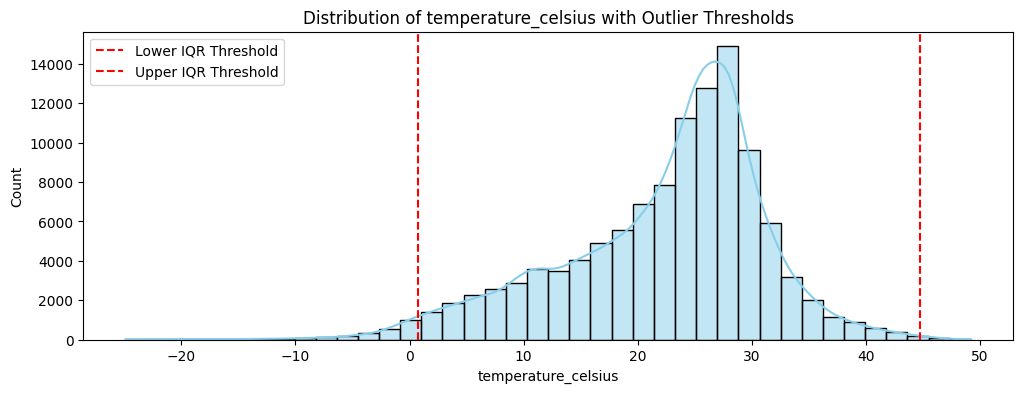

In [46]:
plt.figure(figsize=(12,4))
sns.histplot(df['temperature_celsius'], bins=40, kde=True, color="skyblue")
plt.axvline(lower_limit, color='red', linestyle='--', label='Lower IQR Threshold')
plt.axvline(upper_limit, color='red', linestyle='--', label='Upper IQR Threshold')
plt.title(f"Distribution of {'temperature_celsius'} with Outlier Thresholds")
plt.legend()
plt.show()

### Outlier Analysis(Column-wise)

In [47]:
outliers_list = []
for col in numerical_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1

  lower_limit = Q1 - 1.5*IQR
  upper_limit = Q3 + 1.5*IQR
  outliers=df[(df[col]<lower_limit) | (df[col]>upper_limit)]
  count=len(outliers)
  percent=(count/len(df))*100
  outliers_list.append([col,count,percent,lower_limit,upper_limit])

outliers_df = pd.DataFrame(outliers_list, columns=['Feature', 'Outliers', 'Percent', 'Lower_Limit', 'Upper_Limit'])
outliers_df.sort_values(by='Outliers', ascending=False, inplace=True)
outliers_df.reset_index(drop=True, inplace=True)


In [48]:
outliers_df

,Feature,Outliers,Percent,Lower_Limit,Upper_Limit
0,visibility_km,22655,20.112213,1.000000e+01,1.000000e+01
1,visibility_miles,22511,19.984375,6.000000e+00,6.000000e+00
2,precip_mm,21191,18.812532,-4.500000e-02,7.500000e-02
3,precip_in,17749,15.756860,0.000000e+00,0.000000e+00
4,air_quality_Sulphur_dioxide,15350,13.627123,-1.088750e+01,2.061250e+01
5,air_quality_PM10,11976,10.631819,-3.878250e+01,9.223750e+01
6,air_quality_Nitrogen_dioxide,11968,10.624717,-2.321750e+01,4.264250e+01
7,air_quality_gb-defra-index,11407,10.126683,-2.000000e+00,6.000000e+00
8,air_quality_Carbon_Monoxide,10208,9.062259,-1.802000e+02,8.878000e+02
9,air_quality_PM2.5,9550,8.478112,-2.469750e+01,6.040250e+01


In [49]:
from scipy import stats

temp_zscore = np.abs(stats.zscore(df_ind['temperature_celsius']))
anomalies_temp = df_ind[np.abs(temp_zscore) > 2]


In [50]:
anomalies_temp

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,month
6310,India,New Delhi,28.6,77.2,Asia/Kolkata,1718545500,2024-06-16 19:15:00,44.8,112.7,Clear,...,62.300,2,3,05:23 AM,07:21 PM,02:08 PM,01:18 AM,Waxing Gibbous,67,6
6694,India,New Delhi,28.6,77.2,Asia/Kolkata,1718719200,2024-06-18 19:30:00,44.1,111.5,Clear,...,80.300,2,2,05:24 AM,07:22 PM,03:59 PM,02:15 AM,Waxing Gibbous,83,6
40061,India,New Delhi,28.6,77.2,Asia/Kolkata,1733741100,2024-12-09 16:15:00,19.1,66.4,Mist,...,114.145,4,10,07:03 AM,05:25 PM,01:00 PM,12:18 AM,Waxing Gibbous,51,12
42791,India,New Delhi,28.6,77.2,Asia/Kolkata,1734950700,2024-12-23 16:15:00,14.3,57.8,Patchy rain nearby,...,260.110,6,10,07:11 AM,05:30 PM,12:13 AM,12:26 PM,Last Quarter,52,12
45520,India,New Delhi,28.6,77.2,Asia/Kolkata,1736159400,2025-01-06 16:00:00,14.4,57.9,Fog,...,222.185,5,10,07:15 AM,05:40 PM,11:34 AM,No moonset,Waxing Crescent,36,1
45695,India,New Delhi,28.6,77.2,Asia/Kolkata,1736246700,2025-01-07 16:15:00,16.1,61.0,Fog,...,150.405,4,10,07:15 AM,05:40 PM,12:06 PM,12:18 AM,First Quarter,47,1
46264,India,New Delhi,28.6,77.2,Asia/Kolkata,1736506800,2025-01-10 16:30:00,17.4,63.3,Overcast,...,257.520,6,10,07:15 AM,05:43 PM,02:07 PM,03:38 AM,Waxing Gibbous,80,1
46459,India,New Delhi,28.6,77.2,Asia/Kolkata,1736591400,2025-01-11 16:00:00,14.3,57.7,Moderate or heavy rain with thunder,...,273.060,6,10,07:15 AM,05:43 PM,03:00 PM,04:46 AM,Waxing Gibbous,88,1
46654,India,New Delhi,28.6,77.2,Asia/Kolkata,1736675100,2025-01-12 15:15:00,15.0,59.0,Mist,...,147.815,4,10,07:15 AM,05:44 PM,04:00 PM,05:52 AM,Waxing Gibbous,94,1
46849,India,New Delhi,28.6,77.2,Asia/Kolkata,1736762400,2025-01-13 15:30:00,16.3,61.3,Mist,...,200.725,5,10,07:15 AM,05:45 PM,05:05 PM,06:50 AM,Waxing Gibbous,98,1


In [51]:
from scipy import stats
import numpy as np
z_outliers = {}
outlier_rows = {}
for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df_ind[col]))
    z_outliers[col] = (z_scores > 3).sum()
    outlier_rows[col] = df_ind[z_scores > 3]
print("Number of Z-score outliers in each column:")
for col, count in z_outliers.items():
    print(f"{col}: {count}")

Number of Z-score outliers in each column:
latitude: 0
longitude: 0
last_updated_epoch: 0
temperature_celsius: 0
temperature_fahrenheit: 0
wind_mph: 6
wind_kph: 6
wind_degree: 0
pressure_mb: 0
pressure_in: 0
precip_mm: 14
precip_in: 14
humidity: 0
cloud: 0
feels_like_celsius: 0
feels_like_fahrenheit: 0
visibility_km: 0
visibility_miles: 0
uv_index: 0
gust_mph: 6
gust_kph: 6
air_quality_Carbon_Monoxide: 12
air_quality_Ozone: 1
air_quality_Nitrogen_dioxide: 8
air_quality_Sulphur_dioxide: 5
air_quality_PM2.5: 4
air_quality_PM10: 15
air_quality_us-epa-index: 0
air_quality_gb-defra-index: 0
moon_illumination: 0


/tmp/ipython-input-1447658009.py:6: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(df_ind[col]))
/tmp/ipython-input-1447658009.py:6: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(df_ind[col]))


Z-score based anomaly detection identifies extreme temperature values that deviate significantly from historical patterns. These anomalies may represent heatwaves or cold spells rather than data errors.

In [52]:
cols=['temperature_celsius','humidity','precip_mm']
for col in cols:
  india_temp_ts = (
      df_ind
      .groupby('last_updated')['temperature_celsius']
      .mean()
  )
  window = 30  # 30-day window

  rolling_mean = india_temp_ts.rolling(window).mean()
  rolling_std = india_temp_ts.rolling(window).std()

  upper_band = rolling_mean + 3 * rolling_std
  lower_band = rolling_mean - 3 * rolling_std

  anomalies_ts = india_temp_ts[
      (india_temp_ts > upper_band) | (india_temp_ts < lower_band)
  ]
  print(f"Anomalies in {col}:")
  print(anomalies_ts.to_frame(name=col))
  print

Anomalies in temperature_celsius:
                     temperature_celsius
last_updated                            
2024-06-21 19:00:00                 31.1
2024-12-23 16:15:00                 14.3
2025-05-02 14:30:00                 27.3
2025-07-31 14:00:00                 26.0
2025-09-30 13:30:00                 23.1
Anomalies in humidity:
                     humidity
last_updated                 
2024-06-21 19:00:00      31.1
2024-12-23 16:15:00      14.3
2025-05-02 14:30:00      27.3
2025-07-31 14:00:00      26.0
2025-09-30 13:30:00      23.1
Anomalies in precip_mm:
                     precip_mm
last_updated                  
2024-06-21 19:00:00       31.1
2024-12-23 16:15:00       14.3
2025-05-02 14:30:00       27.3
2025-07-31 14:00:00       26.0
2025-09-30 13:30:00       23.1


In [53]:
from sklearn.ensemble import IsolationForest

features = df_ind[
    ['temperature_celsius', 'humidity', 'precip_mm', 'pressure_mb']
].dropna()

iso = IsolationForest(contamination=0.01, random_state=42)
df_ind['anomaly_iforest'] = iso.fit_predict(features)

anomalies_ml = df_ind[df_ind['anomaly_iforest'] == -1]
anomalies_ml

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,month,anomaly_iforest
9582,India,New Delhi,28.6,77.2,Asia/Kolkata,1720011600,2024-07-03 18:30:00,26.2,79.2,Moderate or heavy rain with thunder,...,4,9,05:28 AM,07:23 PM,02:39 AM,05:12 PM,Waning Crescent,10,7,-1
20035,India,New Delhi,28.6,77.2,Asia/Kolkata,1724848200,2024-08-28 18:00:00,30.1,86.2,Moderate or heavy rain with thunder,...,4,10,05:57 AM,06:47 PM,12:13 AM,03:03 PM,Waning Crescent,33,8,-1
42791,India,New Delhi,28.6,77.2,Asia/Kolkata,1734950700,2024-12-23 16:15:00,14.3,57.8,Patchy rain nearby,...,6,10,07:11 AM,05:30 PM,12:13 AM,12:26 PM,Last Quarter,52,12,-1
46459,India,New Delhi,28.6,77.2,Asia/Kolkata,1736591400,2025-01-11 16:00:00,14.3,57.7,Moderate or heavy rain with thunder,...,6,10,07:15 AM,05:43 PM,03:00 PM,04:46 AM,Waxing Gibbous,88,1,-1
86595,India,New Delhi,28.6,77.2,Asia/Kolkata,1754382600,2025-08-05 14:00:00,32.0,89.6,Mist,...,4,10,05:45 AM,07:09 PM,04:19 PM,01:29 AM,Waxing Gibbous,79,8,-1
88350,India,New Delhi,28.6,77.2,Asia/Kolkata,1755159300,2025-08-14 13:45:00,26.1,79.0,Light rain,...,5,10,05:50 AM,07:01 PM,10:07 PM,10:46 AM,Waning Gibbous,77,8,-1


/tmp/ipython-input-1506746041.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


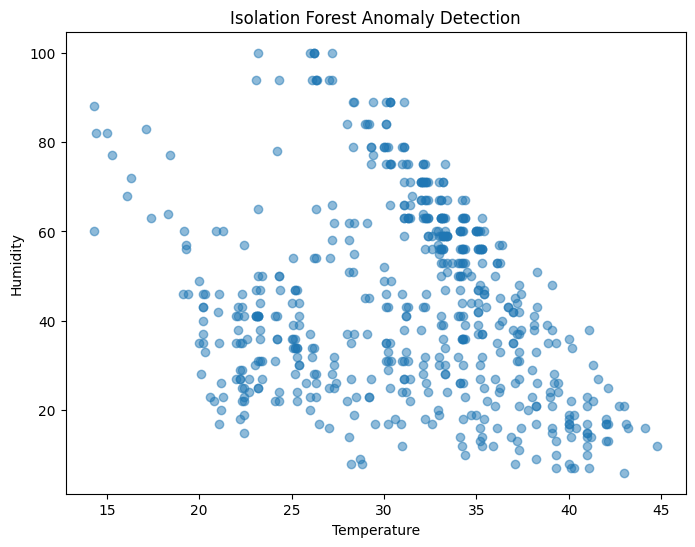

In [54]:
df_india = df[df['country'] == 'India'].copy()

plt.figure(figsize=(8,6))
plt.scatter(
    df_india['temperature_celsius'],
    df_india['humidity'],
    # c=df_india['anomaly_iforest'],
    cmap='coolwarm',
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Isolation Forest Anomaly Detection")
plt.show()


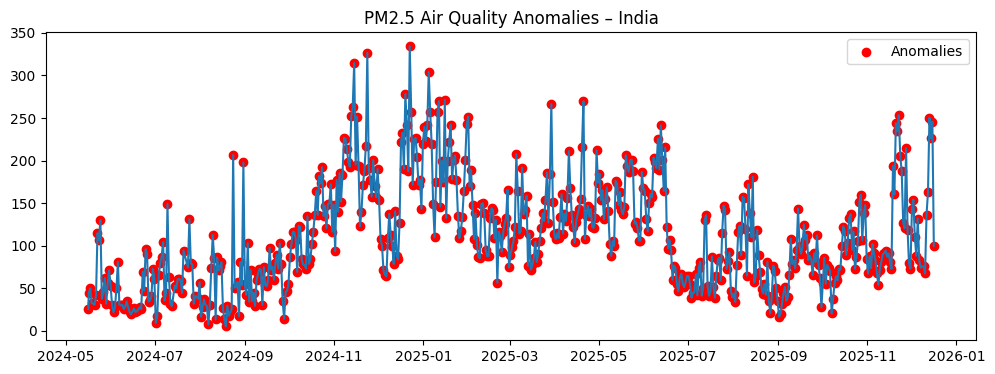

In [55]:
plt.figure(figsize=(12,4))
plt.plot(df_india['last_updated'], df_india['air_quality_PM2.5'])
plt.scatter(
    df_india['last_updated'],
    df_india['air_quality_PM2.5'],
    color='red',
    label='Anomalies'
)
plt.legend()
plt.title("PM2.5 Air Quality Anomalies – India")
plt.show()


Additionally, anomaly detection techniques are applied to identify
extreme weather events and unusual climatic behavior.


Only a small number of anomalies were detected, indicating stable
weather patterns with occasional extreme events rather than noisy data.


### Box plot to discover outliers across columns

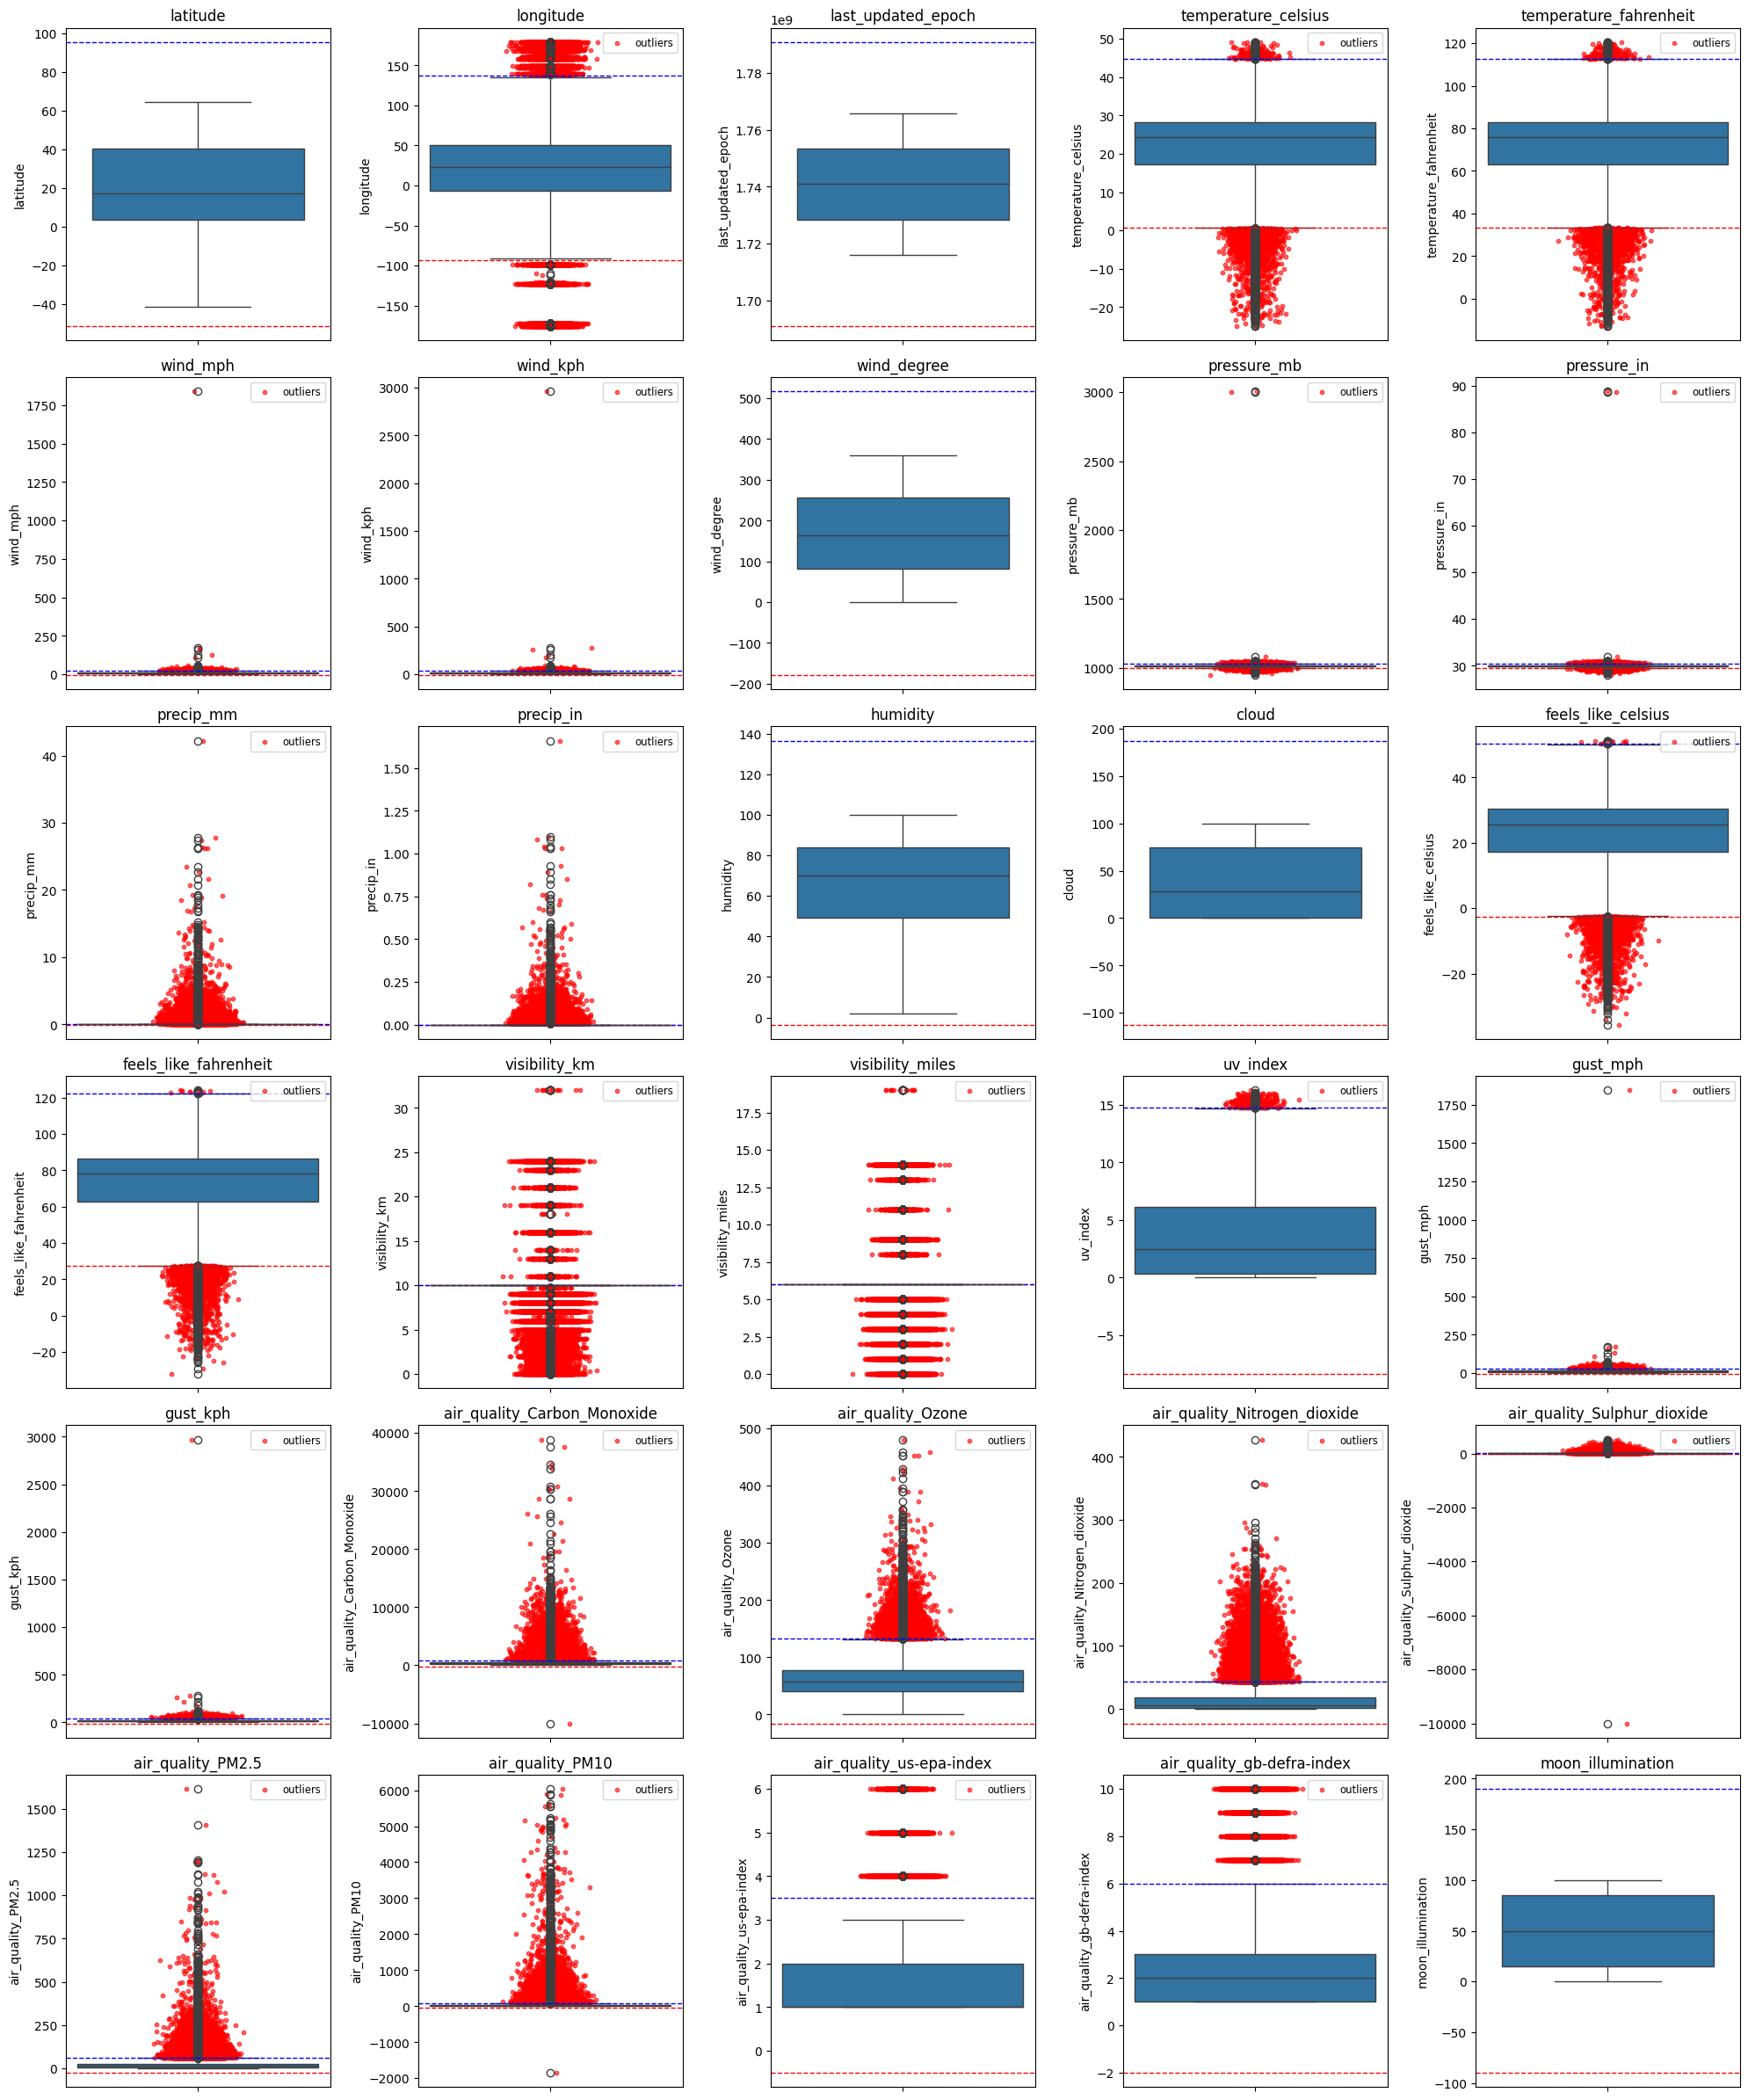

In [56]:
# grid layout
num_cols = 5
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols
plt.figure(figsize=(20, num_rows * 4))

for i, column in enumerate(numerical_cols):
    ax = plt.subplot(num_rows, num_cols, i + 1)

    # compute IQR bounds for THIS column
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # draw boxplot (single-column)
    sns.boxplot(y=df[column], ax=ax)

    # draw bounds as horizontal lines
    ax.axhline(y=lower_bound, color='red', linestyle='--', linewidth=1)
    ax.axhline(y=upper_bound, color='blue', linestyle='--', linewidth=1)

    # overlay the outlier points (if any) as red dots with horizontal jitter
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    outliers = df.loc[outlier_mask, column]
    if len(outliers) > 0:
        # jitter so points don't sit exactly on the center line
        x_jitter = np.random.normal(loc=0.0, scale=0.04, size=len(outliers))
        ax.scatter(x_jitter, outliers, color='red', s=10, alpha=0.6, label='outliers')
        ax.legend(loc='upper right', fontsize='small')

    ax.set_title(column)
    ax.set_xlabel('')


plt.tight_layout()
plt.show()


# Exploratory Data Analysis(EDA)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


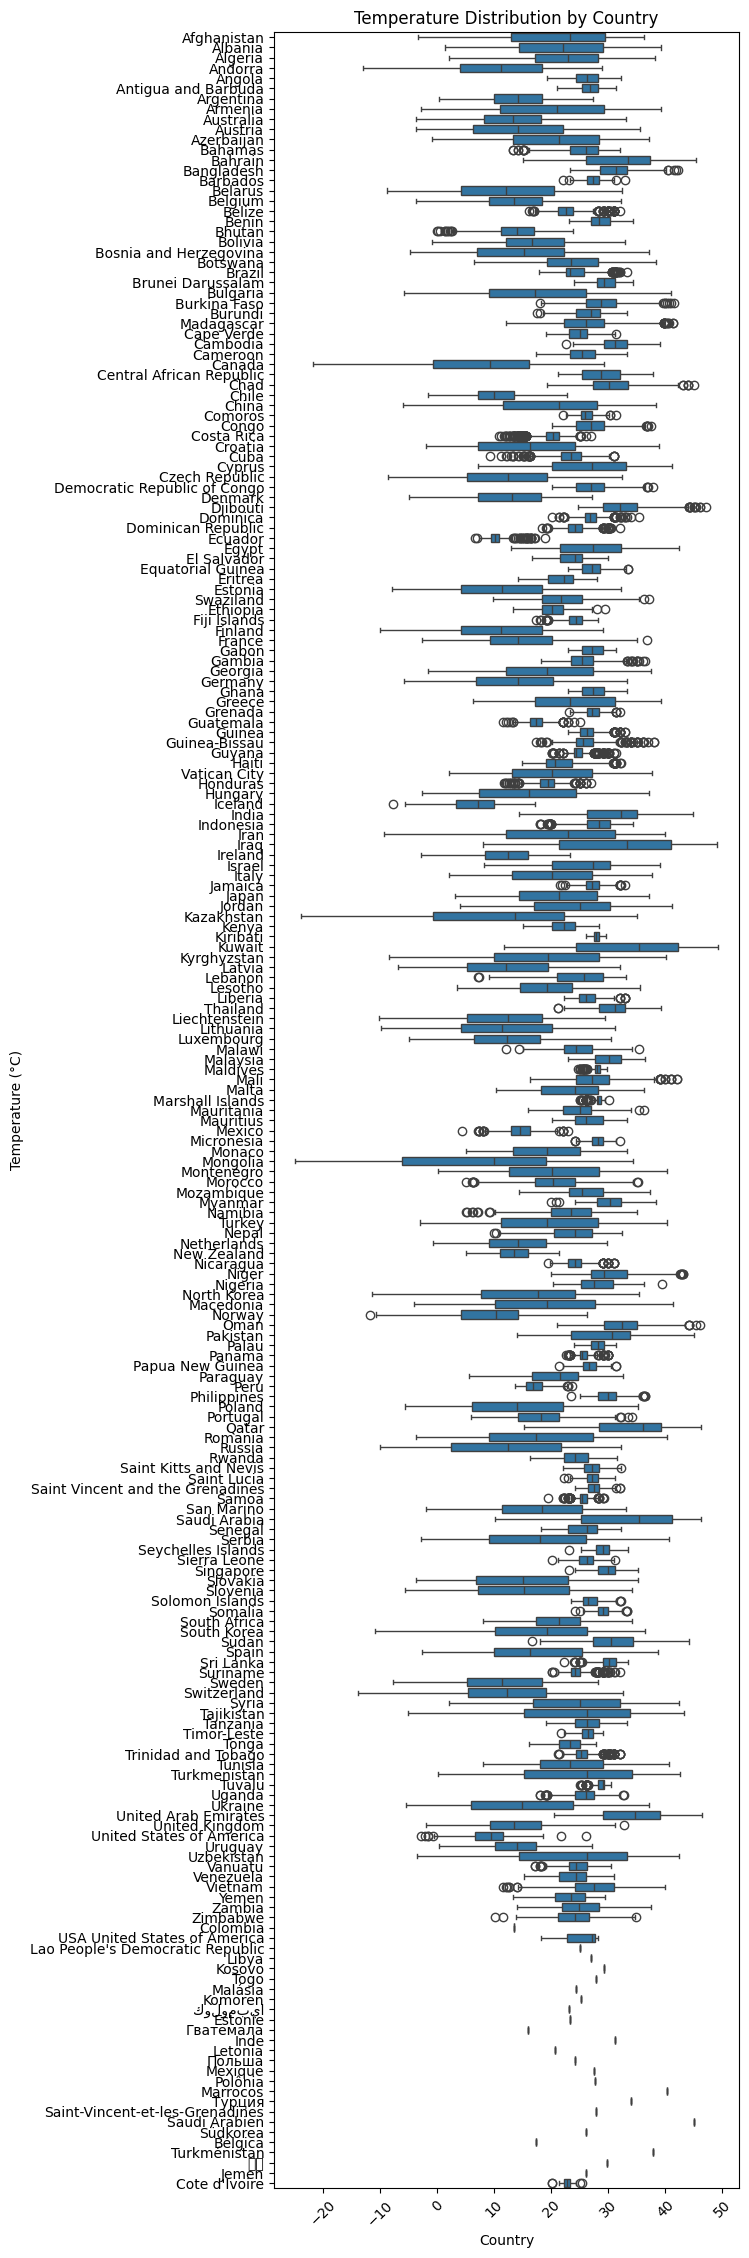

In [57]:
# This is a boxplot visualization that shows how temperature varies across different countries in the dataset.
plt.figure(figsize=(6, 28))
sns.boxplot(x='temperature_celsius', y='country', data=df)

plt.xticks(rotation=45)
plt.title('Temperature Distribution by Country')
plt.ylabel('Temperature (°C)')
plt.xlabel('Country')

plt.show()


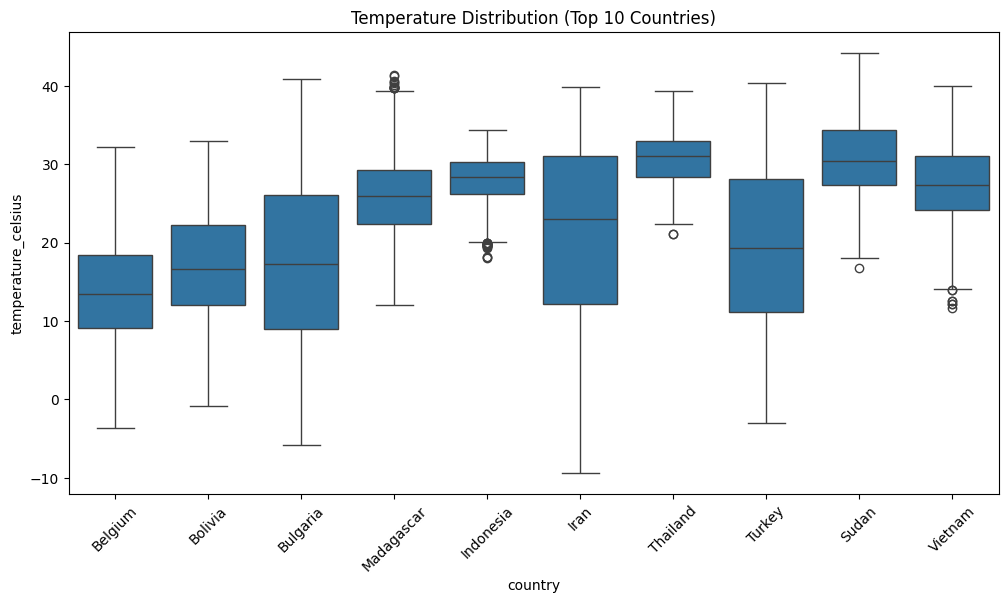

In [58]:
# Show only top 10 countries with most cities
top10 = df['country'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(x='country', y='temperature_celsius', data=df[df['country'].isin(top10)])
plt.xticks(rotation=45)
plt.title('Temperature Distribution (Top 10 Countries)')
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


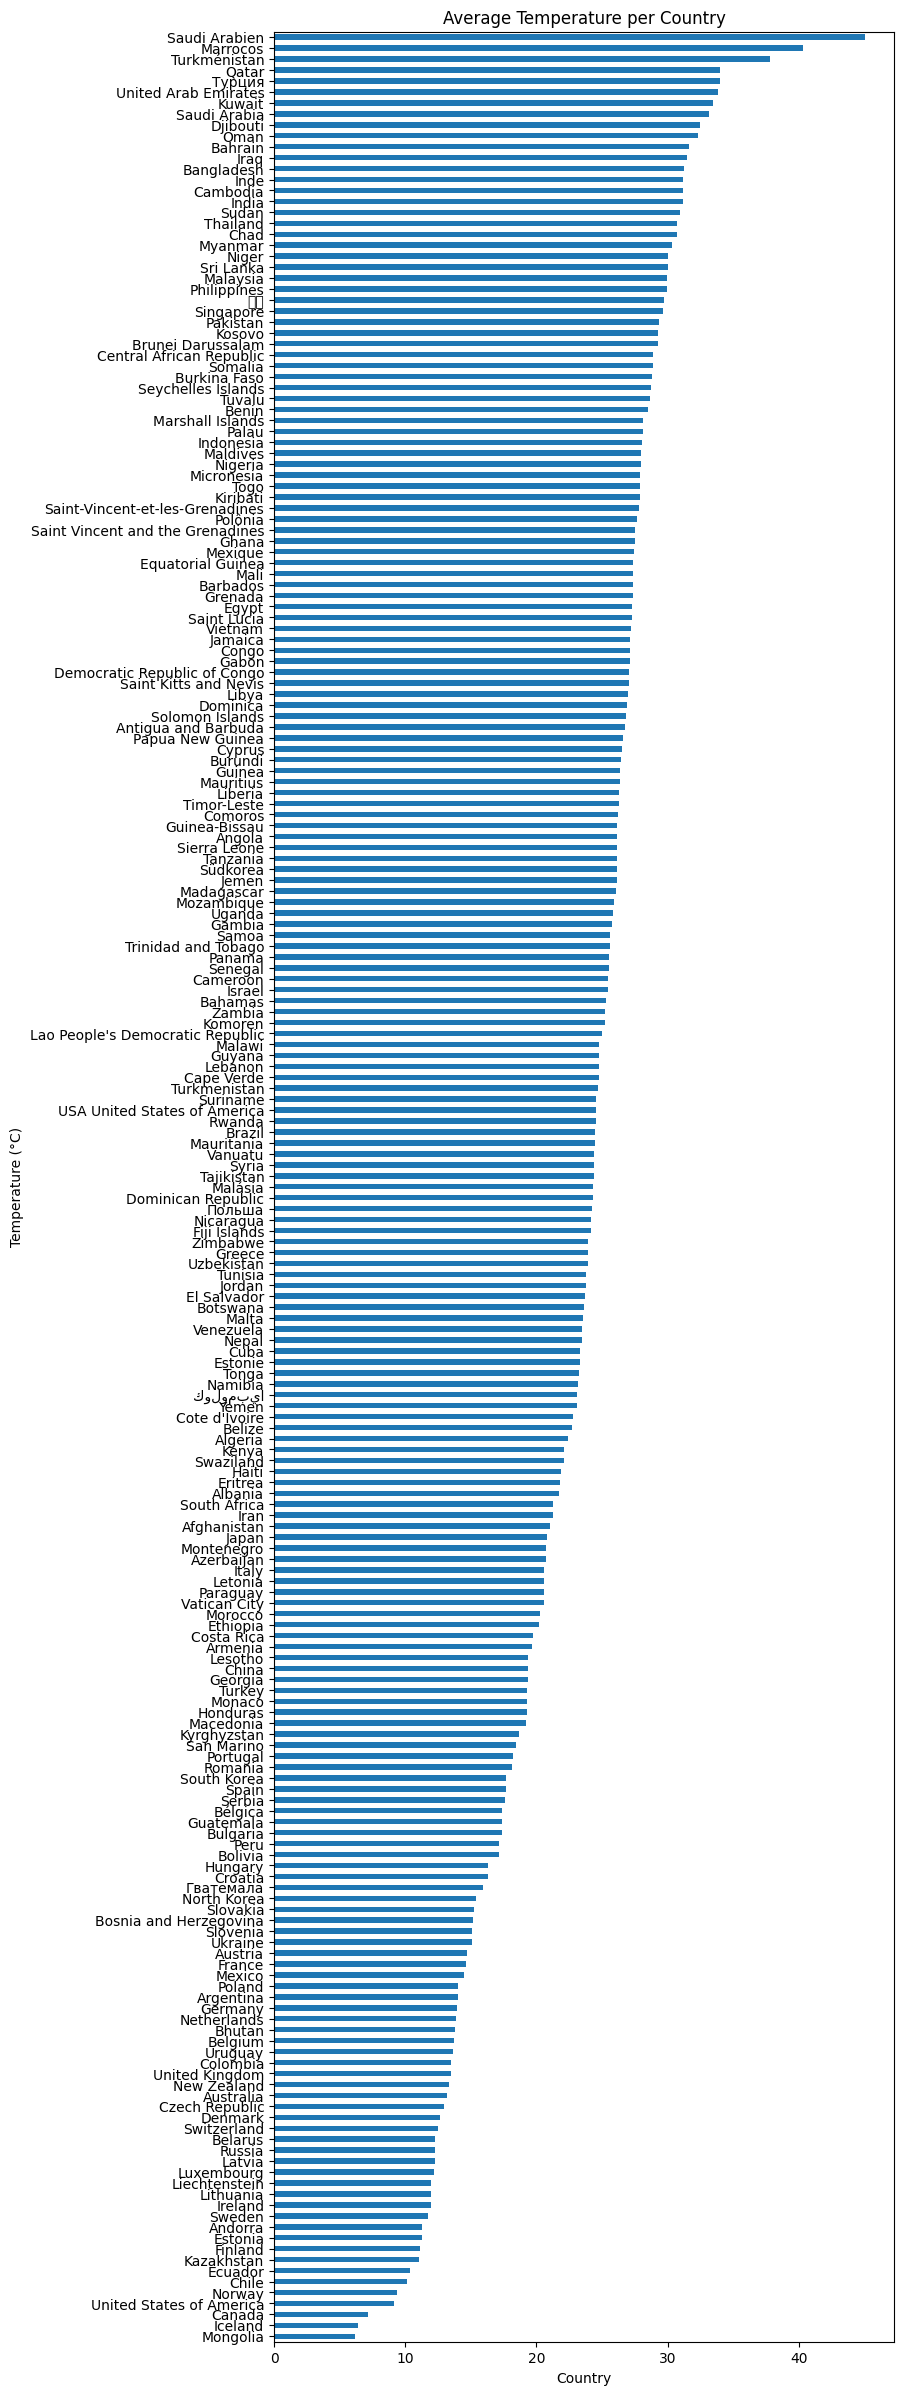

In [59]:
# Aggregate first, then plot a simpler bar chart
country_mean = df.groupby('country')['temperature_celsius'].mean().sort_values()

plt.figure(figsize=(8,30))
country_mean.plot(kind='barh')
plt.title("Average Temperature per Country")
plt.ylabel("Temperature (°C)")
plt.xlabel("Country")
plt.show()


### Data distribution over years

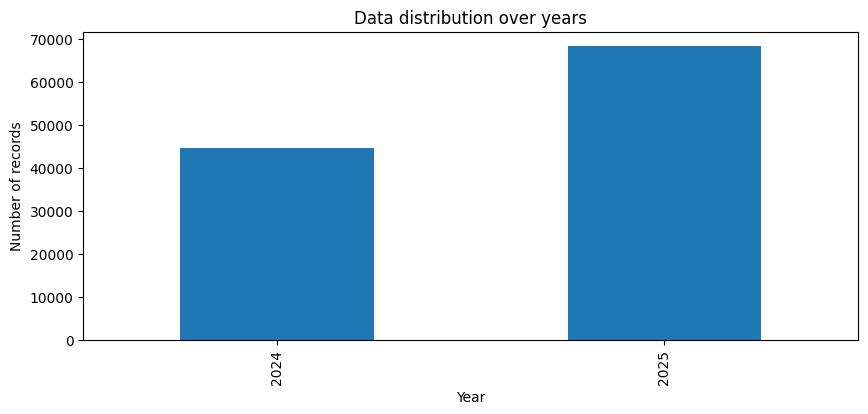

In [60]:
# df['last_updated'] = pd.to_datetime(df['last_updated'])

df['year'] = df['last_updated'].dt.year
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title("Data distribution over years")
plt.xlabel("Year")
plt.ylabel("Number of records")
plt.show()


In [61]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df_india = df[df['country'] == 'India'].copy()
df_india.shape

(577, 43)

In [62]:
selected_cols = [
     'last_updated','temperature_celsius',
    'condition_text', 'wind_direction', 'moon_phase',
    'wind_kph', 'wind_degree', 'gust_kph',
    'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index',
    'feels_like_celsius', 'visibility_km',
    'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10',
    'air_quality_us-epa-index', 'air_quality_gb-defra-index','year','month'
]

df_india = df_india[selected_cols]

df_india

,last_updated,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,year,month
77,2024-05-16 14:15:00,42.0,Mist,NNW,Waxing Gibbous,11.2,330,18.4,1008.0,0.0,...,307.10,144.5,3.00,6.10,25.40,64.00,2,3,2024,5
272,2024-05-16 19:30:00,38.0,Mist,NE,Waxing Gibbous,11.2,50,13.4,1005.0,0.0,...,741.00,120.2,22.60,22.90,44.00,80.80,3,5,2024,5
467,2024-05-17 21:30:00,36.0,Mist,N,Waxing Gibbous,3.6,10,8.7,1003.0,0.0,...,907.90,88.7,24.70,19.30,49.70,83.70,3,6,2024,5
659,2024-05-18 20:00:00,41.0,Mist,WNW,Waxing Gibbous,11.2,300,29.0,1000.0,0.0,...,454.00,128.8,8.40,10.40,32.50,58.70,2,3,2024,5
853,2024-05-19 19:45:00,41.0,Mist,WNW,Waxing Gibbous,11.2,290,21.1,999.0,0.0,...,527.40,113.0,12.70,11.70,31.70,55.00,2,3,2024,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111745,2025-12-12 13:00:00,22.1,Mist,NW,Last Quarter,3.6,313,10.8,1017.0,0.0,...,1848.85,28.0,64.35,63.95,163.35,164.25,5,10,2025,12
111940,2025-12-13 12:45:00,24.2,Overcast,ESE,Waning Crescent,5.0,111,5.8,1018.0,0.0,...,3349.85,10.0,99.15,86.95,250.45,253.25,6,10,2025,12
112135,2025-12-14 12:45:00,22.4,Overcast,WSW,Waning Crescent,3.6,246,10.8,1019.0,0.0,...,4763.85,16.0,79.75,82.55,226.25,226.65,5,10,2025,12
112330,2025-12-15 13:00:00,18.4,Fog,WNW,Waning Crescent,10.8,297,12.4,1019.0,0.0,...,2489.85,57.0,87.65,83.65,245.75,248.55,5,10,2025,12


In [63]:
df_country = df_india.sort_values('last_updated')

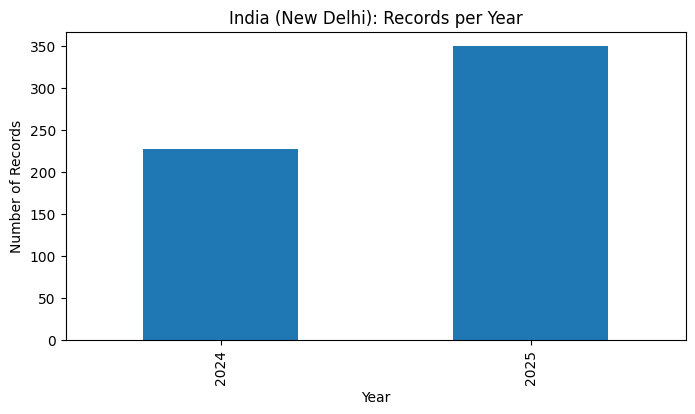

In [64]:
df_country['year'].value_counts().sort_index().plot(kind='bar', figsize=(8,4))
plt.title("India (New Delhi): Records per Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.show()


# Climate Analyses

## Spatial Analysis

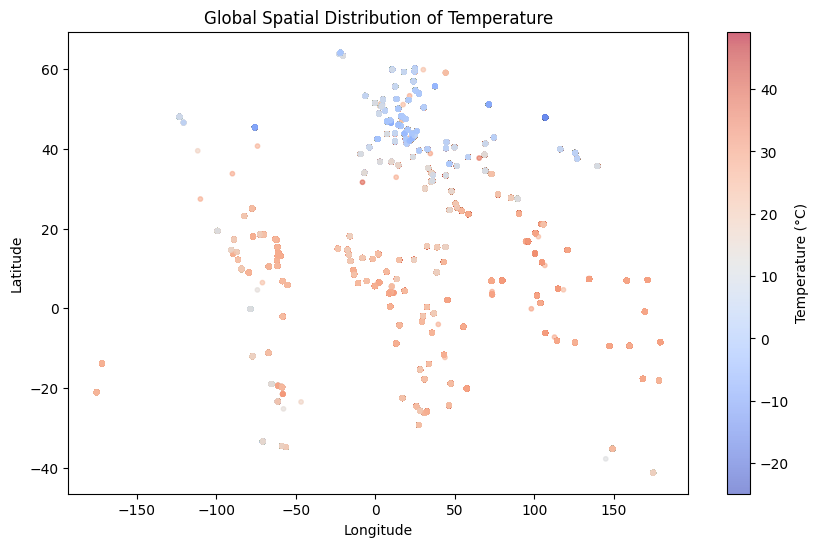

In [65]:
plt.figure(figsize=(10,6))
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['temperature_celsius'],
    cmap='coolwarm',
    alpha=0.6,
    s=10
)
plt.colorbar(label='Temperature (°C)')
plt.title("Global Spatial Distribution of Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


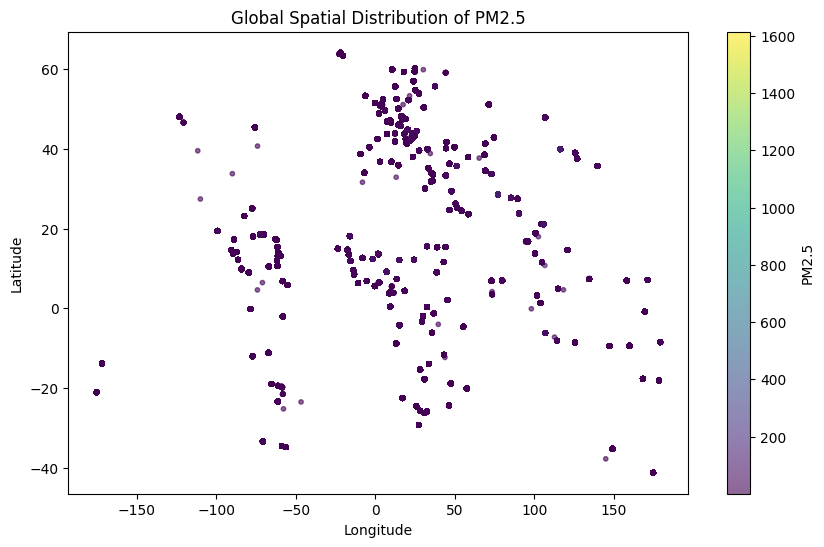

In [66]:
plt.figure(figsize=(10,6))
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['air_quality_PM2.5'],
    cmap='viridis',
    alpha=0.6,
    s=10
)
plt.colorbar(label='PM2.5')
plt.title("Global Spatial Distribution of PM2.5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


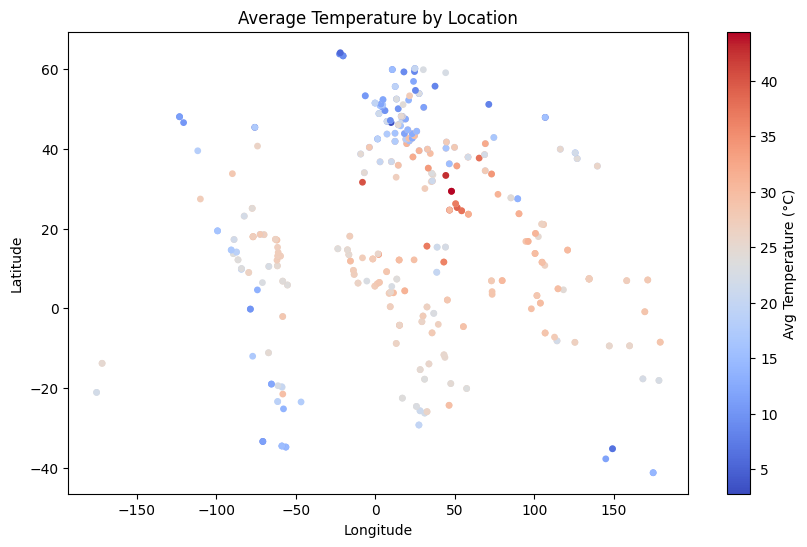

In [67]:
location_avg = (
    df.groupby(['latitude','longitude'])['temperature_celsius']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))
plt.scatter(
    location_avg['longitude'],
    location_avg['latitude'],
    c=location_avg['temperature_celsius'],
    cmap='coolwarm',
    s=15
)
plt.colorbar(label='Avg Temperature (°C)')
plt.title("Average Temperature by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Spatial analysis was performed using latitude and longitude coordinates
to visualize geographical weather patterns. Global temperature
distribution reveals clear latitudinal gradients, with higher
temperatures concentrated near equatorial regions and cooler conditions
towards higher latitudes.

Air quality spatial visualization highlights regional pollution clusters,
particularly over densely populated and industrialized areas. Country-
level analysis for India further reveals intra-regional variations,
demonstrating the influence of geography on local climate conditions.

These spatial patterns emphasize the strong relationship between
geography, climate zones, and environmental conditions.


## 6. Country-Specific Analysis: India

Only weather data corresponding to **India** is selected for time series modeling.
This ensures the model learns country-specific seasonal patterns.


In [68]:
df_india.columns

Index(['last_updated', 'temperature_celsius', 'condition_text',
       'wind_direction', 'moon_phase', 'wind_kph', 'wind_degree', 'gust_kph',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index',
       'feels_like_celsius', 'visibility_km', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'year',
       'month'],
      dtype='object')

## Temperature trend over time

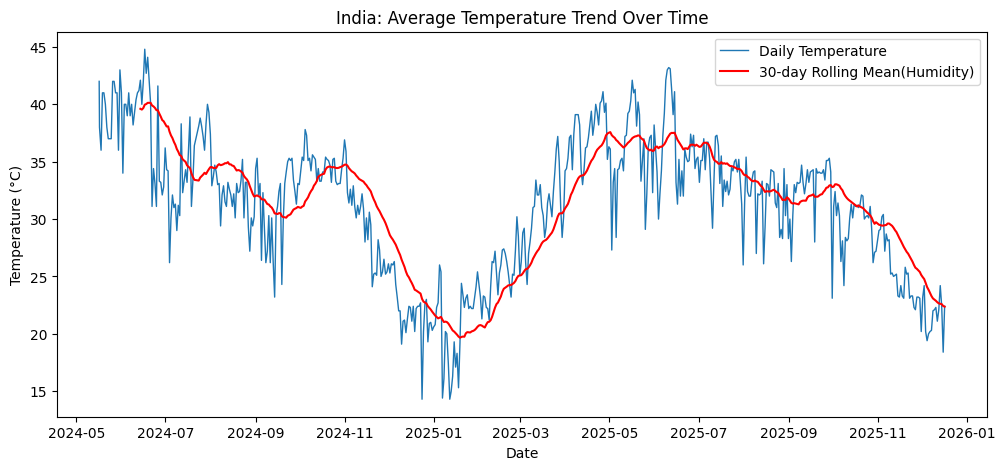

In [69]:
india_temp_ts = (
    df_india
    .groupby('last_updated')['temperature_celsius']
    .mean()
)
rolling_temp = india_temp_ts.rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(india_temp_ts, linewidth=1, label="Daily Temperature")
plt.plot(rolling_temp, color='red', label="30-day Rolling Mean(Humidity)")
plt.legend()
plt.title("India: Average Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()


## Monthly average temperature (Seasonality)

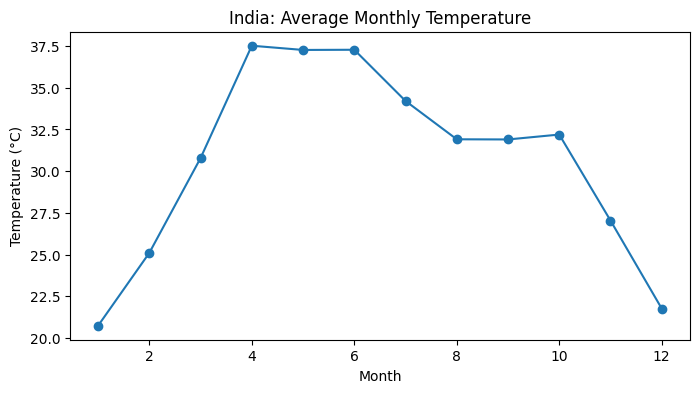

In [70]:
monthly_temp_india = (
    df_india
    .groupby('month')['temperature_celsius']
    .mean()
)

plt.figure(figsize=(8,4))
monthly_temp_india.plot(marker='o')
plt.title("India: Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()


## Temperature distribution

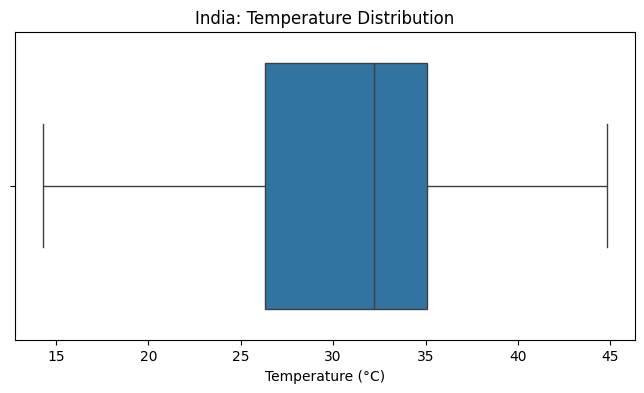

In [71]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_india['temperature_celsius'])
plt.title("India: Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.show()


## Precipitation trend over time

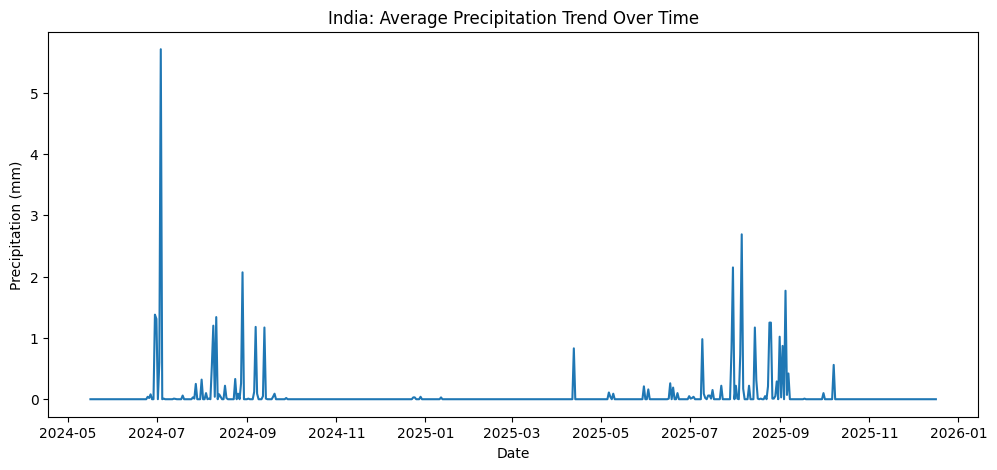

In [72]:
india_precip_ts = (
    df_india
    .groupby('last_updated')['precip_mm']
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(india_precip_ts)
plt.title("India: Average Precipitation Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.show()


## Monthly precipitation (Monsoon pattern)

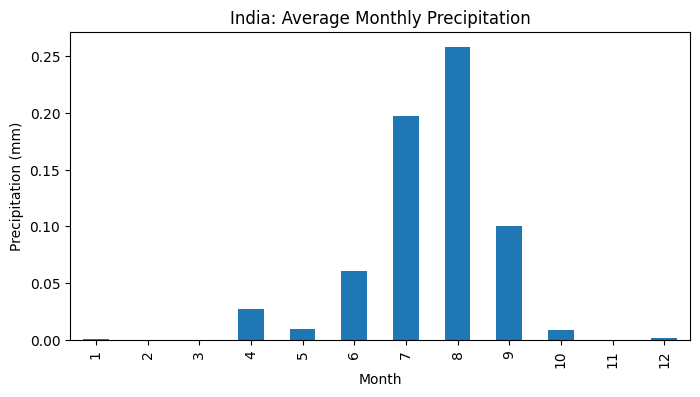

In [73]:
monthly_precip_india = (
    df_india
    .groupby('month')['precip_mm']
    .mean()
)

plt.figure(figsize=(8,4))
monthly_precip_india.plot(kind='bar')
plt.title("India: Average Monthly Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()


## Precipitation distribution

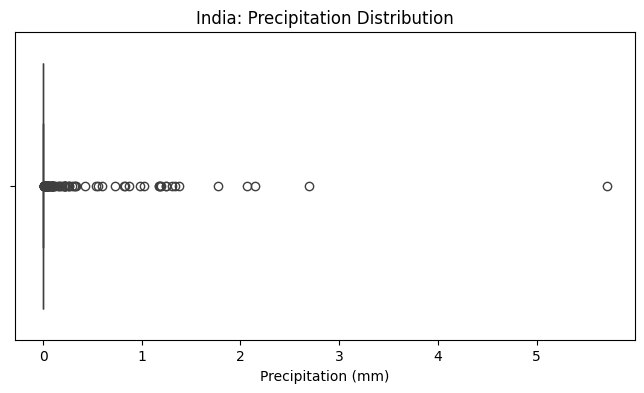

In [74]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_india['precip_mm'])
plt.title("India: Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.show()


## Correlation Analysis

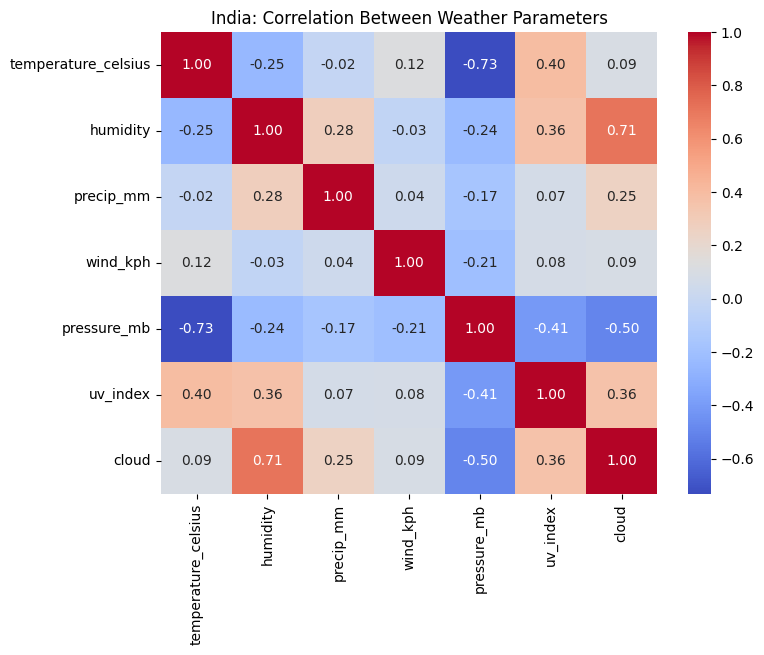

In [75]:
num_cols = [
    'temperature_celsius',
    'humidity',
    'precip_mm',
    'wind_kph',
    'pressure_mb',
    'uv_index',
    'cloud'
]

plt.figure(figsize=(8,6))
sns.heatmap(
    df_india[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("India: Correlation Between Weather Parameters")
plt.show()


The exploratory data analysis reveals strong seasonal patterns in India’s temperature and precipitation, particularly evident in monthly trends. Clear correlations exist between humidity, precipitation, and atmospheric pressure. These findings justify the use of time-series forecasting models using the last_updated feature for India-specific weather prediction.

In [76]:
ts_temp_daily = (
    df_india.set_index('last_updated',inplace=False)['humidity']
    .resample('D')
    .mean()
    .interpolate(method='time')
)

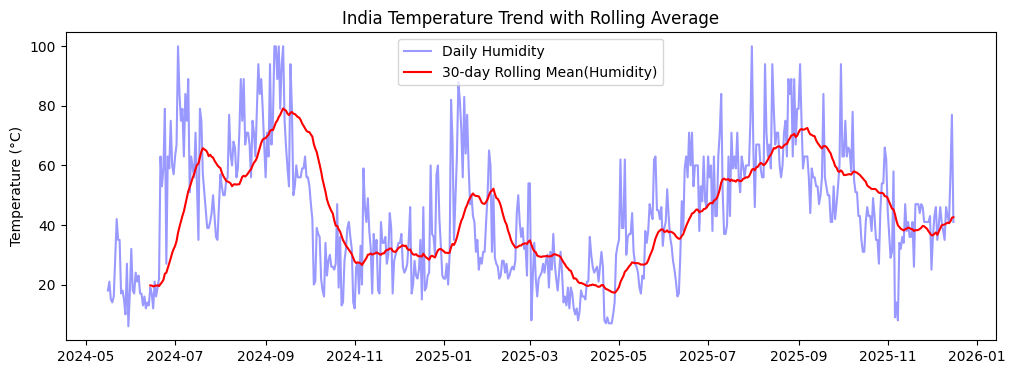

In [77]:
rolling_temp = ts_temp_daily.rolling(window=30).mean()

plt.figure(figsize=(12,4))
plt.plot(ts_temp_daily, color='blue', alpha=0.4, label="Daily Humidity")
plt.plot(rolling_temp, color='red', label="30-day Rolling Mean(Humidity)")
plt.legend()
plt.title("India Temperature Trend with Rolling Average")
plt.ylabel("Temperature (°C)")
plt.show()


In [78]:
df_india

,last_updated,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,...,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,year,month
77,2024-05-16 14:15:00,42.0,Mist,NNW,Waxing Gibbous,11.2,330,18.4,1008.0,0.0,...,307.10,144.5,3.00,6.10,25.40,64.00,2,3,2024,5
272,2024-05-16 19:30:00,38.0,Mist,NE,Waxing Gibbous,11.2,50,13.4,1005.0,0.0,...,741.00,120.2,22.60,22.90,44.00,80.80,3,5,2024,5
467,2024-05-17 21:30:00,36.0,Mist,N,Waxing Gibbous,3.6,10,8.7,1003.0,0.0,...,907.90,88.7,24.70,19.30,49.70,83.70,3,6,2024,5
659,2024-05-18 20:00:00,41.0,Mist,WNW,Waxing Gibbous,11.2,300,29.0,1000.0,0.0,...,454.00,128.8,8.40,10.40,32.50,58.70,2,3,2024,5
853,2024-05-19 19:45:00,41.0,Mist,WNW,Waxing Gibbous,11.2,290,21.1,999.0,0.0,...,527.40,113.0,12.70,11.70,31.70,55.00,2,3,2024,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111745,2025-12-12 13:00:00,22.1,Mist,NW,Last Quarter,3.6,313,10.8,1017.0,0.0,...,1848.85,28.0,64.35,63.95,163.35,164.25,5,10,2025,12
111940,2025-12-13 12:45:00,24.2,Overcast,ESE,Waning Crescent,5.0,111,5.8,1018.0,0.0,...,3349.85,10.0,99.15,86.95,250.45,253.25,6,10,2025,12
112135,2025-12-14 12:45:00,22.4,Overcast,WSW,Waning Crescent,3.6,246,10.8,1019.0,0.0,...,4763.85,16.0,79.75,82.55,226.25,226.65,5,10,2025,12
112330,2025-12-15 13:00:00,18.4,Fog,WNW,Waning Crescent,10.8,297,12.4,1019.0,0.0,...,2489.85,57.0,87.65,83.65,245.75,248.55,5,10,2025,12


## Feature Importance

In [79]:
features = [
    'humidity',
    'precip_mm',
    'pressure_mb',
    'wind_kph',
    'uv_index',
    'cloud'
]

X = df_ind[features].dropna()
y = df_ind.loc[X.index, 'temperature_celsius']


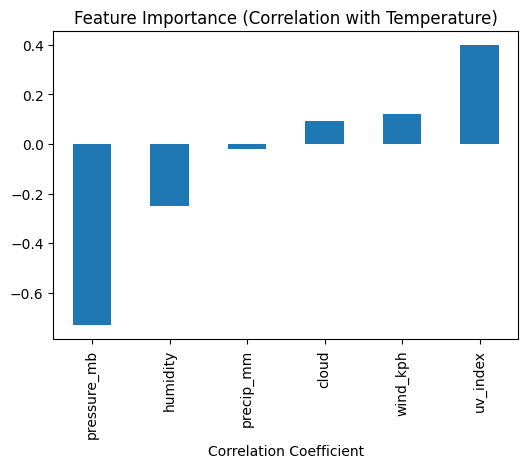

In [110]:
corr_with_temp = X.join(y).corr()['temperature_celsius'].drop('temperature_celsius')

corr_with_temp.sort_values().plot(kind='bar', figsize=(6,4))
plt.title("Feature Importance (Correlation with Temperature)")
plt.xlabel("Correlation Coefficient")
plt.show()


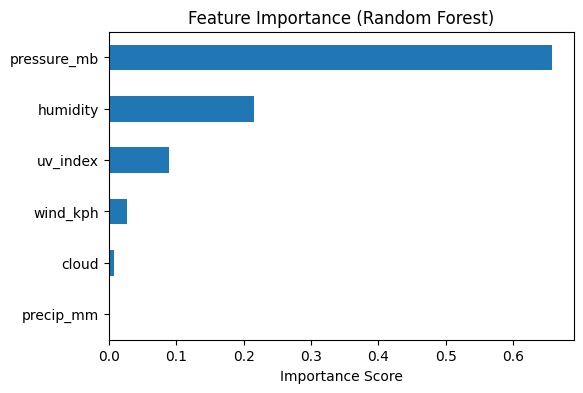

In [81]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X, y)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values()

rf_importance.plot(kind='barh', figsize=(6,4))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()


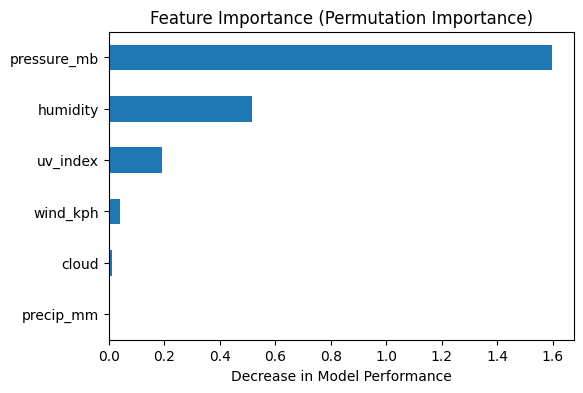

In [82]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X, y,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=features
).sort_values()

perm_importance.plot(kind='barh', figsize=(6,4))
plt.title("Feature Importance (Permutation Importance)")
plt.xlabel("Decrease in Model Performance")
plt.show()


## Geographical Patterns
Weather conditions differ across countries and continents.

In [83]:
country_temp = (
    df.groupby('country')['temperature_celsius']
      .mean()
      .sort_values(ascending=False)
)


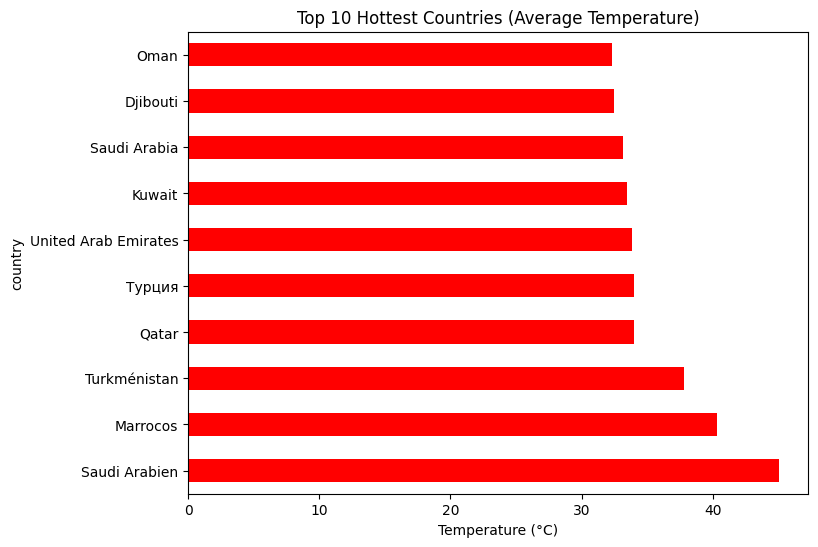

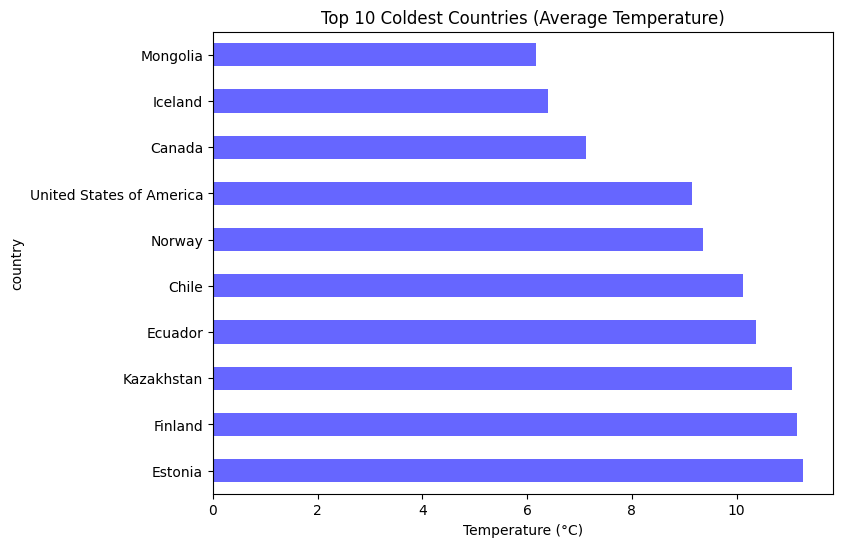

In [84]:
plt.figure(figsize=(8,6))
country_temp.head(10).plot(kind='barh', color='red')
plt.title("Top 10 Hottest Countries (Average Temperature)")
plt.xlabel("Temperature (°C)")
plt.show()

plt.figure(figsize=(8,6))
country_temp.tail(10).plot(kind='barh',alpha=0.6, color='blue')
plt.title("Top 10 Coldest Countries (Average Temperature)")
plt.xlabel("Temperature (°C)")
plt.show()


In [85]:
country_variability = (
    df.groupby('country')['temperature_celsius']
      .std()
      .sort_values(ascending=False)
)


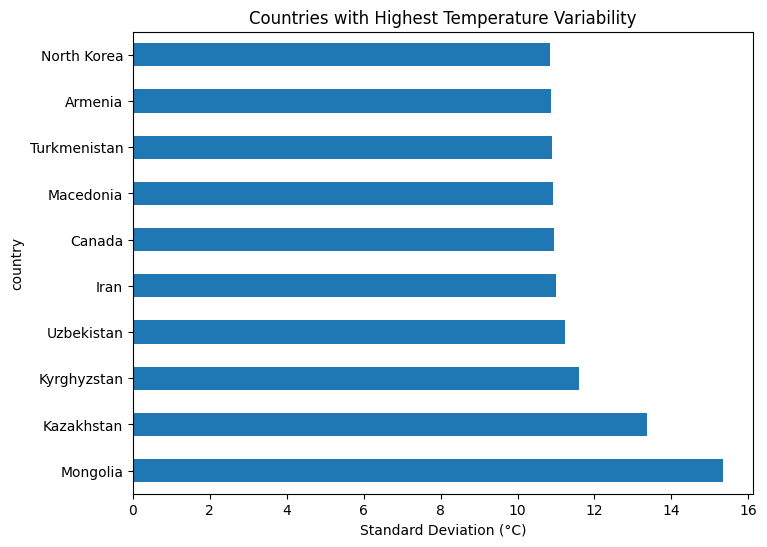

In [86]:
plt.figure(figsize=(8,6))
country_variability.head(10).plot(kind='barh')
plt.title("Countries with Highest Temperature Variability")
plt.xlabel("Standard Deviation (°C)")
plt.show()


## Climate Analysis: Long-Term Trends and Regional Variations

To study long-term climate patterns, weather data was aggregated at yearly
and monthly levels to reduce short-term variability. Global temperature
trends indicate gradual changes over time, reflecting climate-level
behavior rather than daily weather fluctuations.

Country-level analysis reveals distinct regional patterns. Tropical
regions such as India and Brazil exhibit consistently higher average
temperatures, while temperate regions such as the United Kingdom show
lower averages and reduced seasonal amplitude. Climate variability
analysis further highlights differences in temperature stability across
regions.

Monthly aggregation for India demonstrates clear seasonal climate
behavior, with warmer summer months and cooler winter periods, confirming
the presence of strong climatic seasonality.


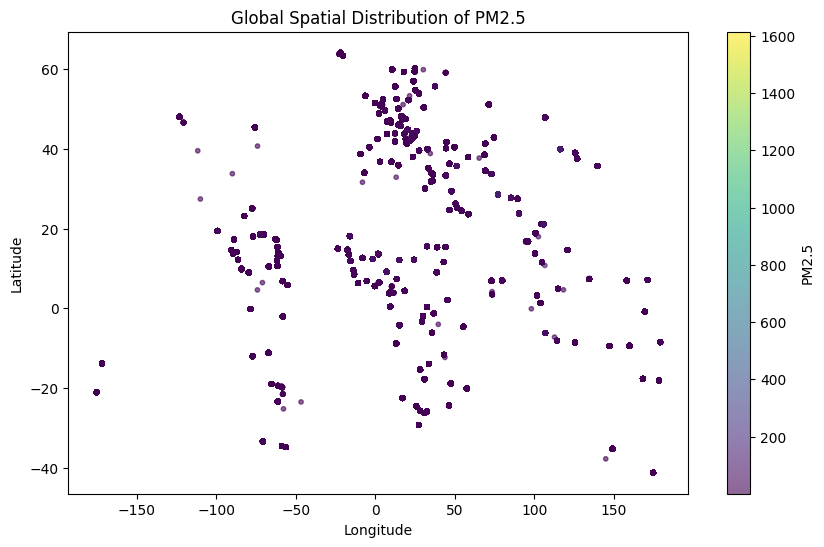

In [87]:
plt.figure(figsize=(10,6))
plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['air_quality_PM2.5'],
    cmap='viridis',
    alpha=0.6,
    s=10
)
plt.colorbar(label='PM2.5')
plt.title("Global Spatial Distribution of PM2.5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


## 7. Time Series Preparation

- `last_updated` is converted to datetime format
- Data is sorted chronologically
- Target variable: Temperature (Celsius)


In [88]:
ts=df_india.drop(columns=['year','month'])
ts.set_index('last_updated', inplace=True)

In [89]:
ts

,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,humidity,...,feels_like_celsius,visibility_km,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 14:15:00,42.0,Mist,NNW,Waxing Gibbous,11.2,330,18.4,1008.0,0.0,13,...,43.0,4.0,307.10,144.5,3.00,6.10,25.40,64.00,2,3
2024-05-16 19:30:00,38.0,Mist,NE,Waxing Gibbous,11.2,50,13.4,1005.0,0.0,23,...,37.1,3.5,741.00,120.2,22.60,22.90,44.00,80.80,3,5
2024-05-17 21:30:00,36.0,Mist,N,Waxing Gibbous,3.6,10,8.7,1003.0,0.0,21,...,34.4,3.5,907.90,88.7,24.70,19.30,49.70,83.70,3,6
2024-05-18 20:00:00,41.0,Mist,WNW,Waxing Gibbous,11.2,300,29.0,1000.0,0.0,15,...,41.4,4.0,454.00,128.8,8.40,10.40,32.50,58.70,2,3
2024-05-19 19:45:00,41.0,Mist,WNW,Waxing Gibbous,11.2,290,21.1,999.0,0.0,14,...,41.4,4.0,527.40,113.0,12.70,11.70,31.70,55.00,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12 13:00:00,22.1,Mist,NW,Last Quarter,3.6,313,10.8,1017.0,0.0,43,...,22.1,1.6,1848.85,28.0,64.35,63.95,163.35,164.25,5,10
2025-12-13 12:45:00,24.2,Overcast,ESE,Waning Crescent,5.0,111,5.8,1018.0,0.0,41,...,23.3,1.0,3349.85,10.0,99.15,86.95,250.45,253.25,6,10
2025-12-14 12:45:00,22.4,Overcast,WSW,Waning Crescent,3.6,246,10.8,1019.0,0.0,57,...,22.4,0.7,4763.85,16.0,79.75,82.55,226.25,226.65,5,10


In [90]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

categorical_cols = ['condition_text', 'wind_direction', 'moon_phase']
encoder = LabelEncoder()
for col in categorical_cols:
    ts[col] = encoder.fit_transform(df_country[col])

ts.head()

,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,humidity,...,feels_like_celsius,visibility_km,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 14:15:00,42.0,6,6,7,11.2,330,18.4,1008.0,0.0,13,...,43.0,4.0,307.1,144.5,3.0,6.1,25.4,64.0,2,3
2024-05-16 19:30:00,38.0,6,4,7,11.2,50,13.4,1005.0,0.0,23,...,37.1,3.5,741.0,120.2,22.6,22.9,44.0,80.8,3,5
2024-05-17 21:30:00,36.0,6,3,7,3.6,10,8.7,1003.0,0.0,21,...,34.4,3.5,907.9,88.7,24.7,19.3,49.7,83.7,3,6
2024-05-18 20:00:00,41.0,6,14,7,11.2,300,29.0,1000.0,0.0,15,...,41.4,4.0,454.0,128.8,8.4,10.4,32.5,58.7,2,3
2024-05-19 19:45:00,41.0,6,14,7,11.2,290,21.1,999.0,0.0,14,...,41.4,4.0,527.4,113.0,12.7,11.7,31.7,55.0,2,3


In [91]:
numerical_cols = ts.select_dtypes(include=['number']).columns.difference(['temperature_celsius','last_updated'])
scaler = MinMaxScaler()
ts[numerical_cols] = scaler.fit_transform(ts[numerical_cols])
ts.head()

,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,humidity,...,feels_like_celsius,visibility_km,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 14:15:00,42.0,0.428571,0.400000,1.0,0.239748,0.918768,0.398374,0.575758,0.0,0.074468,...,0.830028,0.361702,0.000000,0.498276,0.000000,0.003753,0.061380,0.035169,0.2,0.222222
2024-05-16 19:30:00,38.0,0.428571,0.266667,1.0,0.239748,0.134454,0.262873,0.484848,0.0,0.180851,...,0.662890,0.308511,0.075829,0.414483,0.102484,0.108825,0.117899,0.045682,0.4,0.444444
2024-05-17 21:30:00,36.0,0.428571,0.200000,1.0,0.000000,0.022409,0.135501,0.424242,0.0,0.159574,...,0.586402,0.308511,0.104997,0.305862,0.113464,0.086309,0.135219,0.047497,0.4,0.555556
2024-05-18 20:00:00,41.0,0.428571,0.933333,1.0,0.239748,0.834734,0.685637,0.333333,0.0,0.095745,...,0.784703,0.361702,0.025673,0.444138,0.028235,0.030646,0.082955,0.031852,0.2,0.222222
2024-05-19 19:45:00,41.0,0.428571,0.933333,1.0,0.239748,0.806723,0.471545,0.303030,0.0,0.085106,...,0.784703,0.361702,0.038500,0.389655,0.050719,0.038777,0.080524,0.029537,0.2,0.222222


In [112]:
adf=ts.copy()
adf

,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,humidity,...,feels_like_celsius,visibility_km,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 14:15:00,42.0,0.428571,0.400000,1.000000,0.239748,0.918768,0.398374,0.575758,0.0,0.074468,...,0.830028,0.361702,0.000000,0.498276,0.000000,0.003753,0.061380,0.035169,0.2,0.222222
2024-05-16 19:30:00,38.0,0.428571,0.266667,1.000000,0.239748,0.134454,0.262873,0.484848,0.0,0.180851,...,0.662890,0.308511,0.075829,0.414483,0.102484,0.108825,0.117899,0.045682,0.4,0.444444
2024-05-17 21:30:00,36.0,0.428571,0.200000,1.000000,0.000000,0.022409,0.135501,0.424242,0.0,0.159574,...,0.586402,0.308511,0.104997,0.305862,0.113464,0.086309,0.135219,0.047497,0.4,0.555556
2024-05-18 20:00:00,41.0,0.428571,0.933333,1.000000,0.239748,0.834734,0.685637,0.333333,0.0,0.095745,...,0.784703,0.361702,0.025673,0.444138,0.028235,0.030646,0.082955,0.031852,0.2,0.222222
2024-05-19 19:45:00,41.0,0.428571,0.933333,1.000000,0.239748,0.806723,0.471545,0.303030,0.0,0.085106,...,0.784703,0.361702,0.038500,0.389655,0.050719,0.038777,0.080524,0.029537,0.2,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12 13:00:00,22.1,0.428571,0.466667,0.285714,0.000000,0.871148,0.192412,0.848485,0.0,0.393617,...,0.237960,0.106383,0.269440,0.096552,0.320784,0.365564,0.480560,0.097904,0.8,1.000000
2025-12-13 12:45:00,24.2,0.571429,0.133333,0.571429,0.044164,0.305322,0.056911,0.878788,0.0,0.372340,...,0.271955,0.042553,0.531759,0.034483,0.502745,0.509413,0.745226,0.153598,1.0,1.000000
2025-12-14 12:45:00,22.4,0.571429,1.000000,0.571429,0.000000,0.683473,0.192412,0.909091,0.0,0.542553,...,0.246459,0.010638,0.778873,0.055172,0.401307,0.481894,0.671691,0.136952,0.8,1.000000


## Augmented Dickey-Fuller (ADF)

In [113]:
from statsmodels.tsa.stattools import adfuller


adf_test = adfuller(adf['temperature_celsius'])
print(f"ADF Statistic: {adf_test[0]}")
print(f"P-value: {adf_test[1]}")

adf['temp_diff'] = adf['temperature_celsius'].diff()
adf['temp_diff'].fillna(adf['temp_diff'].mean(), inplace=True)

ADF Statistic: -2.4929807346671873
P-value: 0.11719154248131364


/tmp/ipython-input-2930390892.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adf['temp_diff'].fillna(adf['temp_diff'].mean(), inplace=True)


## Autocorrelation Function(ACF) and Partial Autocorrelation Function (PACF)

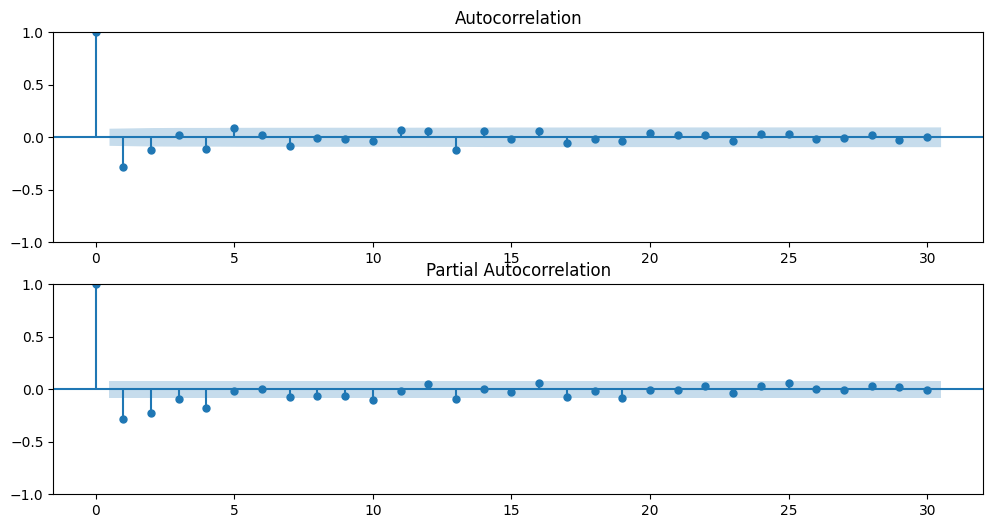

In [114]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(adf['temperature_celsius'].diff().dropna(), lags=30, ax=plt.gca())
plt.subplot(212)
plot_pacf(adf['temperature_celsius'].diff().dropna(), lags=30, ax=plt.gca())
plt.show()

## 8. Train-Test Split

The dataset is split into:
- Training set: Historical data
- Test set: Recent unseen data for evaluation


In [92]:
train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

In [93]:
train.head()

,temperature_celsius,condition_text,wind_direction,moon_phase,wind_kph,wind_degree,gust_kph,pressure_mb,precip_mm,humidity,...,feels_like_celsius,visibility_km,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 14:15:00,42.0,0.428571,0.400000,1.0,0.239748,0.918768,0.398374,0.575758,0.0,0.074468,...,0.830028,0.361702,0.000000,0.498276,0.000000,0.003753,0.061380,0.035169,0.2,0.222222
2024-05-16 19:30:00,38.0,0.428571,0.266667,1.0,0.239748,0.134454,0.262873,0.484848,0.0,0.180851,...,0.662890,0.308511,0.075829,0.414483,0.102484,0.108825,0.117899,0.045682,0.4,0.444444
2024-05-17 21:30:00,36.0,0.428571,0.200000,1.0,0.000000,0.022409,0.135501,0.424242,0.0,0.159574,...,0.586402,0.308511,0.104997,0.305862,0.113464,0.086309,0.135219,0.047497,0.4,0.555556
2024-05-18 20:00:00,41.0,0.428571,0.933333,1.0,0.239748,0.834734,0.685637,0.333333,0.0,0.095745,...,0.784703,0.361702,0.025673,0.444138,0.028235,0.030646,0.082955,0.031852,0.2,0.222222
2024-05-19 19:45:00,41.0,0.428571,0.933333,1.0,0.239748,0.806723,0.471545,0.303030,0.0,0.085106,...,0.784703,0.361702,0.038500,0.389655,0.050719,0.038777,0.080524,0.029537,0.2,0.222222


# 9. Model Building – SARIMAX

SARIMAX is chosen because:
- It handles seasonality
- It supports exogenous variables (if needed)
- Suitable for non-normalized time-series data


In [94]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
y_train = train['temperature_celsius']
X_train = train.drop(columns=['temperature_celsius'])
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1,1,1),              # ARIMA part
    seasonal_order=(1,1,1,12),  # yearly seasonality (monthly cycle)
    enforce_stationarity=False,
    enforce_invertibility=False
)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [95]:
model_fit=model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [96]:
y_test = test['temperature_celsius']
X_test = test.drop(columns=['temperature_celsius'])

sarimax_pred = model_fit.forecast(
    steps=len(test),
    exog=X_test
)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## 11. Model Evaluation

The model is evaluated using:
- MAE
- RMSE

Lower error values indicate better forecasting performance.


In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, sarimax_pred)
rmse = np.sqrt(mean_squared_error(y_test, sarimax_pred))

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")


MAE  : 1.710
RMSE : 2.237


## 10. Forecasting Results

The model forecasts future temperature trends and compares them with actual values.


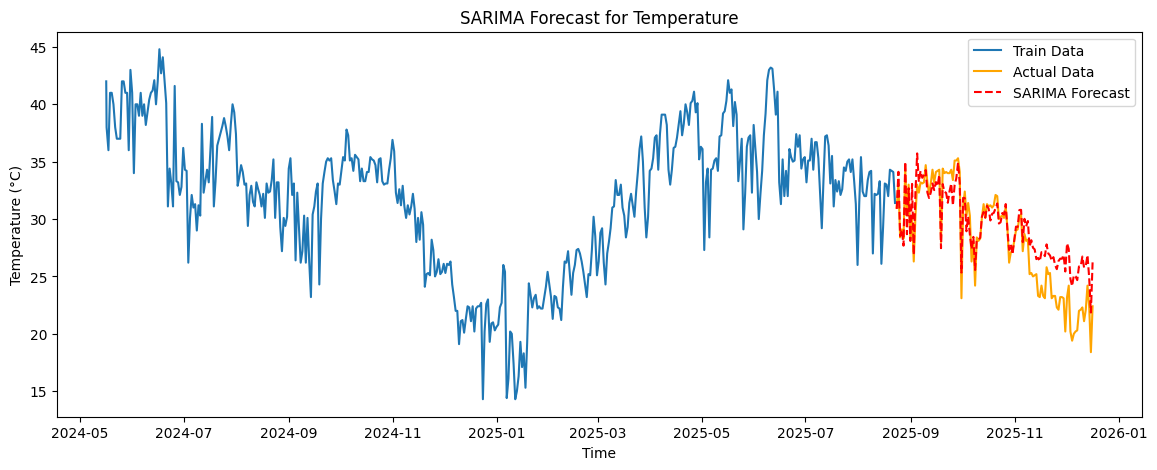

In [98]:
plt.figure(figsize=(14, 5))
plt.plot(X_train.index, train['temperature_celsius'], label="Train Data")
plt.plot(y_test.index, test['temperature_celsius'], label="Actual Data", color="orange")
plt.plot(y_test.index, sarimax_pred, label="SARIMA Forecast", color="red", linestyle="dashed")
plt.legend()
plt.title("SARIMA Forecast for Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()

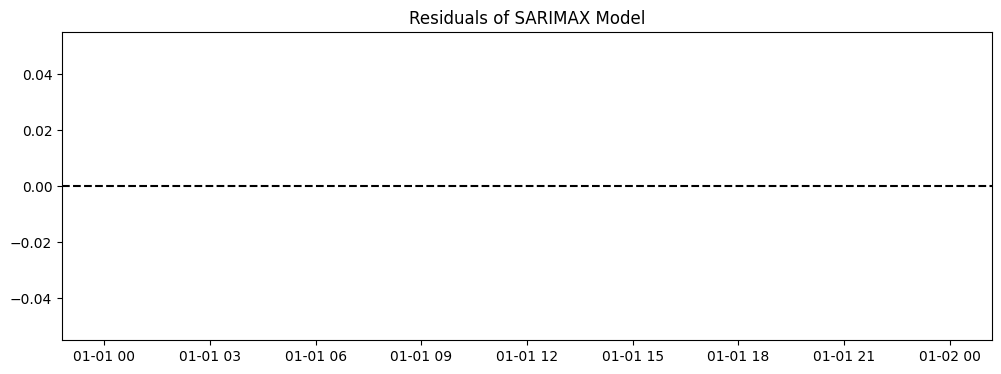

In [99]:
residuals = y_test - sarimax_pred

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals of SARIMAX Model")
plt.axhline(0, color='black', linestyle='--')
plt.show()


## Advanced Modeling – Facebook Prophet

Prophet is an additive time-series model designed to handle:
- Non-linear trends
- Multiple seasonalities
- Missing values and outliers

In this project, Prophet is used as an advanced benchmark model because it automatically
models trend and seasonality and performs well on real-world
business time series.


### Prophet Data Format

Prophet requires the dataset to be in a specific format:
- `ds`: datetime column
- `y`: target variable (temperature in Celsius)


In [100]:
from prophet import Prophet

data = df_india

data = data.reset_index()
data = data.rename(columns={'last_updated': 'ds', 'temperature_celsius': 'y'})
data['ds'] = pd.to_datetime(data['ds'])

prophet_df = data[['ds', 'y']]

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=30, freq='D')

forecast = model.predict(future)

forecast.to_csv("weather_forecast.csv", index=False)
print("Forecasting complete! Results saved to weather_forecast.csv")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Forecasting complete! Results saved to weather_forecast.csv


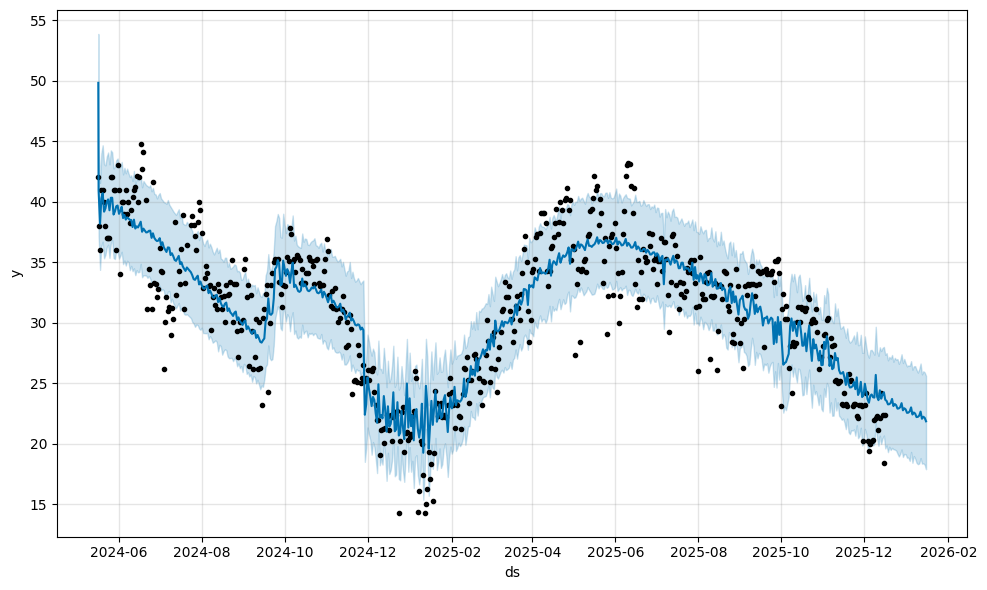

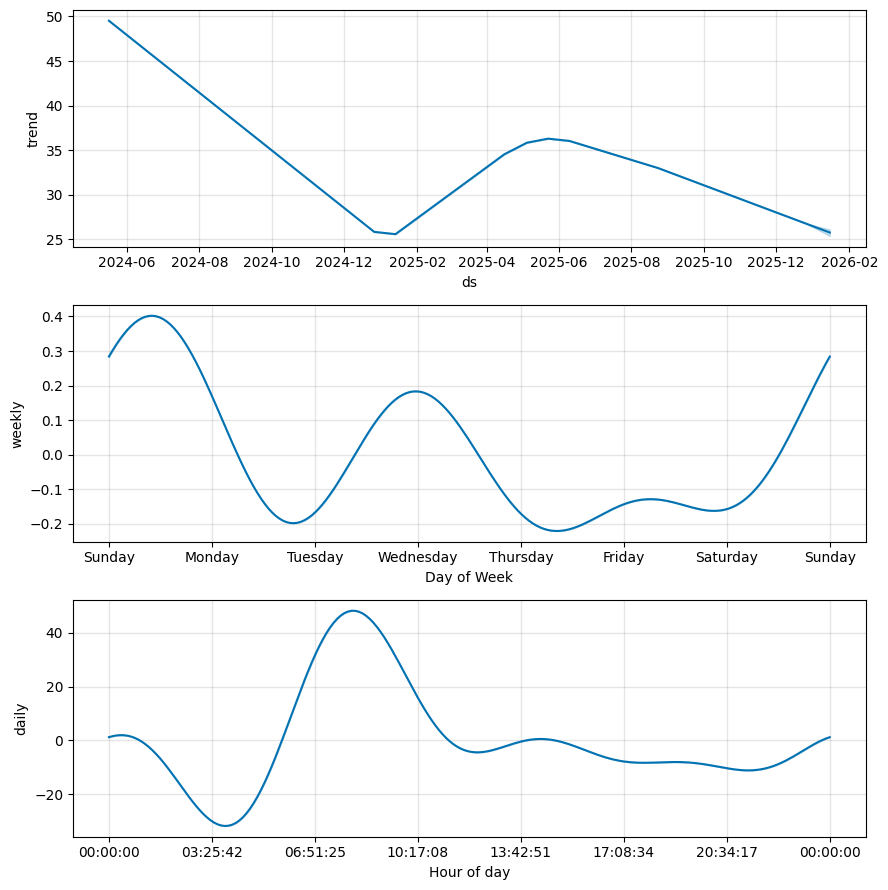

In [101]:
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)
plt.show()

### Prophet Forecast Interpretation

- The black dots represent historical temperature values
- The blue line shows Prophet’s predicted trend
- The shaded region indicates uncertainty intervals


Prophet captures smoother long-term trends compared to SARIMAX,
while SARIMAX reacts more strongly to short-term fluctuations.


In [102]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

evaluation_df = data.merge(forecast[['ds', 'yhat']], on='ds', how='left').dropna()

mae = mean_absolute_error(evaluation_df['y'], evaluation_df['yhat'])
mse = np.sqrt(mean_squared_error(evaluation_df['y'], evaluation_df['yhat']))

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (RMSE): {mse:.3f}")

Mean Absolute Error (MAE): 2.345
Mean Squared Error (RMSE): 2.955


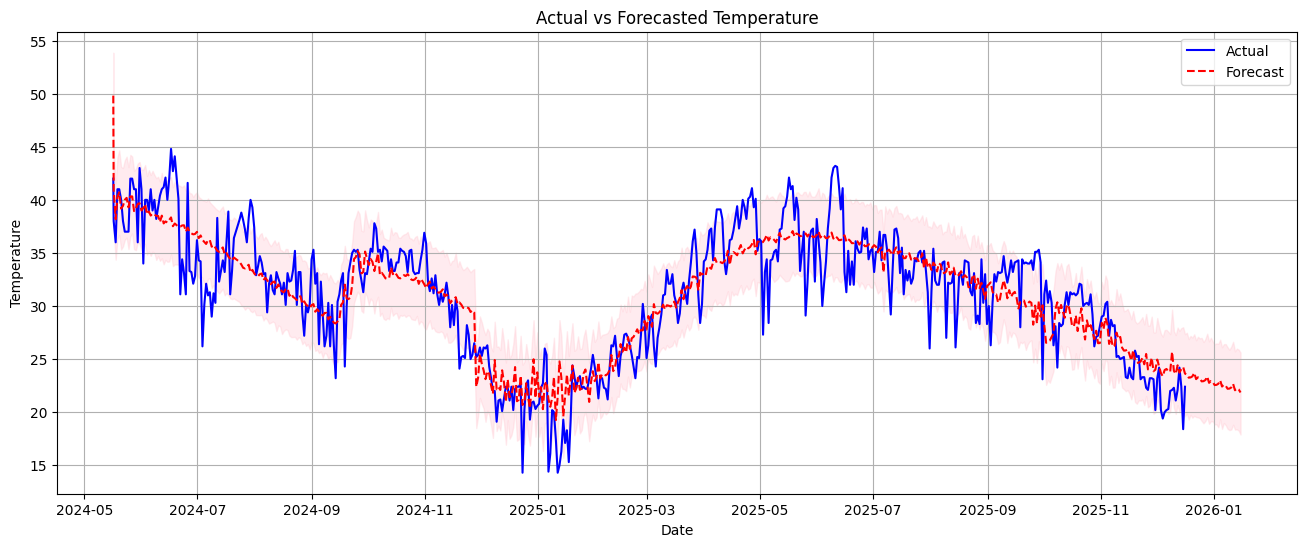

In [107]:
plt.figure(figsize=(16, 6))
plt.plot(data['ds'], data['y'], label='Actual', color='blue')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red', linestyle='dashed')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='pink', alpha=0.3)

plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Actual vs Forecasted Temperature')
plt.legend()
plt.grid()
plt.show()

# Ensemble Model

Implemented a hybrid ensemble model combining SARIMAX and Prophet forecasts to optimize predictive accuracy by leveraging the strengths of both statistical and additive methodologies

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


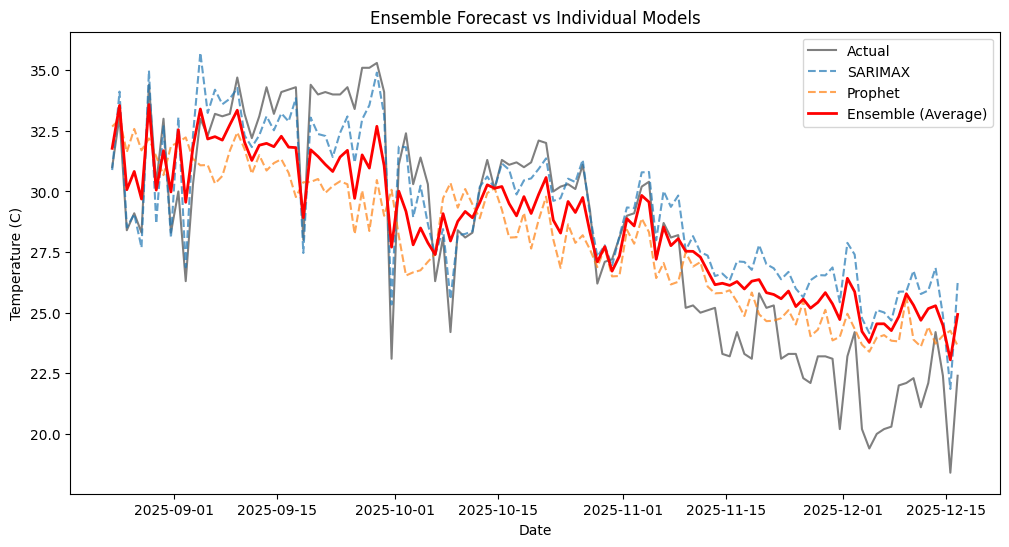

In [109]:
# Retrieve SARIMAX Predictions
sarimax_pred = model_fit.forecast(steps=len(test), exog=X_test)

# Retrieve Prophet Predictions for the same period
prophet_full_forecast = forecast  # This currently holds the Prophet output
test_dates = test.index           # The dates used for testing

# We filter where 'ds' matches our test dates, then set index to 'ds' to align properly
prophet_aligned = prophet_full_forecast[prophet_full_forecast['ds'].isin(test_dates)]
prophet_aligned = prophet_aligned.set_index('ds')

# Extract the predicted values (yhat) ensuring the order matches the test index
prophet_pred_series = prophet_aligned.loc[test_dates]['yhat']

# Create Ensemble (Average)
# Simple averaging of the two models
ensemble_pred = (sarimax_pred + prophet_pred_series.values) / 2

# Evaluate & Visualize
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Calculate Error Metrics for the Ensemble
mae_ensemble = mean_absolute_error(test['temperature_celsius'], ensemble_pred)
rmse_ensemble = np.sqrt(mean_squared_error(test['temperature_celsius'], ensemble_pred))



# Visual Comparison
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['temperature_celsius'], label='Actual', color='black', alpha=0.5)
plt.plot(test.index, sarimax_pred, label='SARIMAX', linestyle='--', alpha=0.7)
plt.plot(test.index, prophet_pred_series, label='Prophet', linestyle='--', alpha=0.7)
plt.plot(test.index, ensemble_pred, label='Ensemble (Average)', linewidth=2, color='red')

plt.title("Ensemble Forecast vs Individual Models")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.show()

## Ensemble Model Performance

In [105]:
print(f"--- Ensemble Model Performance ---")
print(f"Ensemble MAE  : {mae_ensemble:.3f}")
print(f"Ensemble RMSE : {rmse_ensemble:.3f}")

--- Ensemble Model Performance ---
Ensemble MAE  : 1.921
Ensemble RMSE : 2.274


## Model Comparison

| Model     | Strengths | Limitations |
|----------|-----------|-------------|
| SARIMAX  | Statistical control, interpretable | Needs manual tuning |
| Prophet  | Automatic seasonality, robust | Less flexible for exogenous vars |

SARIMAX provides more control over statistical assumptions,
while Prophet offers faster modeling with automatic seasonality handling.


## Key Insights
- India shows strong seasonal temperature and precipitation patterns.
- Weather anomalies are rare but significant, often linked to extreme events.
- Air quality is strongly influenced by wind speed and humidity.
- Humidity and pressure are key drivers of temperature variability.
- SARIMAX captures short-term dynamics better, while Prophet models long-term trends.
